# Part 1 — Data preprocessing (SCE)

In this part, I import and clean the SCE data.

The steps are:
1. import and merge the yearly `sce_extract_YYYY.csv` files,
2. forward-fill selected variables that are only asked in the initial wave,
3. drop all observations from 2025,
4. drop observations with missing values in the variables used in the analysis,
5. remove outliers in the four expectations variables using the 1st and 99th percentiles,
6. create three optimism indicator variables.

The SCE term paper data includes the variables `userid`, `wid`, `date`, `infl_1y`, `house_price_change`, `prob_unrate_up`, `prob_stocks_up`, and several demographic and household characteristics. Some variables, such as `owner`, `health`, and `age_init`, are recorded in the first interview and then carried forward across waves. :contentReference[oaicite:0]{index=0} :contentReference[oaicite:1]{index=1}

In [17]:
# Import required packages
import os
from pathlib import Path
import yfinance as yf
import numpy as np
import pandas as pd

In [18]:
# Define relative path to data folder (IMPORTANT for submission)
DATA_PATH = Path("./data")

# Target variables (main expectations variables used later in the analysis)
TARGET_VARS = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up",
]

# Variables that are only asked in the first survey wave
# These will be forward-filled within each individual
FIRST_WAVE_VARS = [
    "owner",
    "health",
    "age_init",
]

# Control variables (demographics, expectations, etc.)
# These can easily be modified later
CONTROL_VARS = [
    "age_init", "female", "black", "hispanic", "educ",
    "working", "self_employed", "hh_inc_bin", "hh_inc_bin_rank",
    "couple", "num_kids", "owner", "health",
    "financial_past_12m", "financial_12m",
    "prob_miss_paym_3m", "prob_move_house", "prob_irate_up",
    "earnings_change", "hh_inc_change", "hh_spending_change",
    "taxes_change", "take_fin_risk",
    "num_lit_q1_correct", "num_lit_q2_correct",
    "num_lit_q3_correct", "num_lit_q5_correct",
    "num_lit_q6_correct", "num_lit_q8_correct",
    "num_lit_q9_correct",
]

# ID variables (always keep these)
ID_VARS = ["userid", "wid", "date", "year"]

# Combine all variables to keep (remove duplicates with set)
ALL_VARS = sorted(set(ID_VARS[:-1] + TARGET_VARS + FIRST_WAVE_VARS + CONTROL_VARS))

In [19]:
def get_sce_filepaths(data_path: Path):
    """
    Return a sorted list of all SCE CSV files in the data folder.
    """
    return sorted(data_path.glob("sce_extract_*.csv"))


def load_sce_data(data_path: Path, usecols=None):
    """
    Load and merge all yearly SCE files into one DataFrame.
    
    Parameters:
        data_path: path to data folder
        usecols: list of columns to import (reduces memory usage)
    """
    filepaths = get_sce_filepaths(data_path)

    # Check that files exist
    if not filepaths:
        raise FileNotFoundError("No SCE files found in data folder")

    dfs = []

    for filepath in filepaths:
        # Extract year from filename (e.g. sce_extract_2013.csv → 2013)
        year = int(filepath.stem.split("_")[-1])

        # Read CSV file
        df_year = pd.read_csv(filepath, usecols=usecols)

        # Add year column
        df_year["year"] = year

        dfs.append(df_year)

    # Combine all years into one DataFrame
    df = pd.concat(dfs, ignore_index=True)

    return df

In [20]:
def sample_summary(df, label):
    """
    Create a summary of the dataset:
    - number of observations
    - number of individuals
    - number of survey waves
    - first and last survey date
    """
    return pd.DataFrame({
        "sample": [label],
        "n_observations": [len(df)],
        "n_individuals": [df["userid"].nunique()],
        "n_waves": [df["wid"].nunique()],
        "first_date": [df["date"].min()],
        "last_date": [df["date"].max()],
    })

In [21]:
def add_drop_log(log, step, before, after):
    """
    Track how many observations are dropped at each step.
    """
    log.append({
        "step": step,
        "n_before": before,
        "n_after": after,
        "n_dropped": before - after,
    })

In [22]:
# Load merged dataset (only selected columns)
df = load_sce_data(DATA_PATH, usecols=ALL_VARS)

# Convert date column to datetime format
df["date"] = pd.to_datetime(df["date"])

# Store initial sample summary
initial_summary = sample_summary(df, "Initial sample")

initial_summary

,sample,n_observations,n_individuals,n_waves,first_date,last_date
0,Initial sample,180268,23886,143,2013-06-01,2025-05-01


In [23]:
# Sort data by individual and time (required before forward-fill)
df = df.sort_values(["userid", "date"]).copy()

# Forward-fill selected variables within each individual
for col in FIRST_WAVE_VARS:
    df[col] = df.groupby("userid")[col].ffill()

In [24]:
# Initialize log to track dropped observations
drop_log = []

# -------------------------
# Drop all observations from 2025
# -------------------------
before = len(df)
df = df[df["year"] != 2025].copy()
add_drop_log(drop_log, "Drop year 2025", before, len(df))

# -------------------------
# Drop observations with missing values
# -------------------------
analysis_vars = list(set(TARGET_VARS + CONTROL_VARS))

before = len(df)
df = df.dropna(subset=analysis_vars).copy()
add_drop_log(drop_log, "Drop missing values", before, len(df))

In [25]:
# Remove extreme values using 1st and 99th percentiles
for col in TARGET_VARS:
    
    # Compute percentiles
    p1 = df[col].quantile(0.01)
    p99 = df[col].quantile(0.99)

    before = len(df)

    # Keep only observations within bounds
    df = df[(df[col] > p1) & (df[col] < p99)].copy()

    add_drop_log(drop_log, f"Trim outliers in {col}", before, len(df))

In [26]:
# Indicator: optimistic about unemployment (expects < 50% chance of increase)
df["optimist_unrate"] = (df["prob_unrate_up"] < 50).astype(int)

# Indicator: optimistic about stock market (expects > 50% chance of increase)
df["optimist_stocks"] = (df["prob_stocks_up"] > 50).astype(int)

# Indicator: optimistic about house prices (expects positive price change)
df["optimist_house_price"] = (df["house_price_change"] > 0).astype(int)

In [27]:
# Convert drop log to DataFrame
drop_log_df = pd.DataFrame(drop_log)

# Final sample summary
final_summary = sample_summary(df, "Final sample")

# Show cleaning steps
drop_log_df

,step,n_before,n_after,n_dropped
0,Drop year 2025,180268,176101,4167
1,Drop missing values,176101,11969,164132
2,Trim outliers in infl_1y,11969,11672,297
3,Trim outliers in house_price_change,11672,11327,345
4,Trim outliers in prob_unrate_up,11327,11067,260
5,Trim outliers in prob_stocks_up,11067,10818,249


In [28]:
# Compare initial and final sample
pd.concat([initial_summary, final_summary], ignore_index=True)

,sample,n_observations,n_individuals,n_waves,first_date,last_date
0,Initial sample,180268,23886,143,2013-06-01,2025-05-01
1,Final sample,10818,10818,117,2015-04-02,2024-12-30


# Part 2 — Data preprocessing (macro/finance)

In this part, I augment the SCE dataset with macroeconomic and financial time series.

The following data sources are used:
- Yahoo Finance: oil prices (WTI), stock market (S&P 500)
- FRED: inflation, house prices, interest rates, unemployment, GDP, exchange rates, mortgage rates

All data are stored locally in the `data/` folder and loaded from disk.

To ensure that only information available at the time of the survey is used:
- daily and monthly data are aligned to the previous month-end,
- quarterly data are aligned to the previous quarter-end.

In addition to levels, I construct changes (e.g. 1-month and 12-month differences) and merge them into the SCE dataset.

In [29]:
# Paths for macro data (use actual tickers as filenames)
MACRO_FILES = {
    "oil": "CL=F.csv",
    "sp500": "^GSPC.csv",
    "cpi": "CPIAUCSL.csv",
    "house_price_index": "USSTHPI.csv",
    "fed_funds": "FEDFUNDS.csv",
    "unrate": "UNRATE.csv",
    "gdp": "GDPC1.csv",
    "dollar": "DTWEXBGS.csv",
    "mortgage": "MORTGAGE30US.csv",
}

In [30]:
# Download Yahoo Finance data and save locally

def download_yahoo_data():
    """
    Download Yahoo Finance data and save using ticker names.
    """

    # WTI oil
    oil = yf.download("CL=F", start="2010-01-01", end="2025-12-31")
    oil.to_csv(DATA_PATH / "CL=F.csv")

    # S&P 500
    sp500 = yf.download("^GSPC", start="2010-01-01", end="2025-12-31")
    sp500.to_csv(DATA_PATH / "^GSPC.csv")

# download_yahoo_data()

In [31]:
def load_macro_series(file_path, series_name):
    """
    Load one macro/finance series from a local file.

    Handles:
    - Yahoo Finance files with extra header rows
    - FRED files with columns observation_date and ticker value
    """

    # First try reading as a standard FRED file
    df_series = pd.read_csv(file_path)
    df_series.columns = df_series.columns.str.strip().str.lower()

    # Case 1: FRED
    if "observation_date" in df_series.columns:
        df_series = df_series.rename(columns={"observation_date": "date"})
        df_series["date"] = pd.to_datetime(df_series["date"])

        # The second column contains the series values
        value_col = df_series.columns[1]
        df_series = df_series[["date", value_col]].rename(columns={value_col: series_name})

    # Case 2: Yahoo Finance with extra header rows
    else:
        df_series = pd.read_csv(file_path, skiprows=2)

        # Rename columns by position, since Yahoo created messy headers
        df_series.columns = ["date", "close", "high", "low", "open", "volume"]

        # Convert date to datetime
        df_series["date"] = pd.to_datetime(df_series["date"])

        # Keep only date and close
        df_series = df_series[["date", "close"]].rename(columns={"close": series_name})

    return df_series.sort_values("date").reset_index(drop=True)

In [32]:
# Load all macro and finance series from local CSV files
macro_raw = {}

for series_name, file_name in MACRO_FILES.items():
    file_path = DATA_PATH / file_name
    macro_raw[series_name] = load_macro_series(file_path, series_name)

FileNotFoundError: [Errno 2] No such file or directory: 'data\\CL=F.csv'

In [ ]:
# Monthly / daily / weekly series
monthly_series = [
    "oil",
    "sp500",
    "cpi",
    "fed_funds",
    "unrate",
    "dollar",
    "mortgage",
]

# Quarterly series
quarterly_series = [
    "gdp",
    "house_price_index",
]

In [ ]:
def to_monthly_last(df_series, series_name):
    """
    Convert a series to month-end frequency using the last available
    observation in each month.
    """
    df_monthly = (
        df_series.set_index("date")
        .resample("M")
        .last()
        .reset_index()
    )

    return df_monthly[["date", series_name]]


def to_quarterly_last(df_series, series_name):
    """
    Convert a series to quarter-end frequency using the last available
    observation in each quarter.
    """
    df_quarterly = (
        df_series.set_index("date")
        .resample("Q")
        .last()
        .reset_index()
    )

    return df_quarterly[["date", series_name]]

In [ ]:
# Store converted series here
macro_monthly = {}
macro_quarterly = {}

# Convert monthly-type series
for series_name in monthly_series:
    macro_monthly[series_name] = to_monthly_last(macro_raw[series_name], series_name)

# Convert quarterly series
for series_name in quarterly_series:
    macro_quarterly[series_name] = to_quarterly_last(macro_raw[series_name], series_name)

C:\Users\simen\AppData\Local\Temp\ipykernel_7656\3426143.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\simen\AppData\Local\Temp\ipykernel_7656\3426143.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\simen\AppData\Local\Temp\ipykernel_7656\3426143.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\simen\AppData\Local\Temp\ipykernel_7656\3426143.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\simen\AppData\Local\Temp\ipykernel_7656\3426143.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")
C:\Users\simen\AppData\Local\Temp\ipykernel_7656\3426143.py:8: FutureWarning: 'M' is deprecated and will 

In [ ]:
def add_macro_changes_monthly(df_series, series_name):
    """
    Add 1-month and 12-month absolute and relative changes
    to a monthly macro series.
    """
    df_series = df_series.sort_values("date").copy()

    # Absolute changes
    df_series[f"{series_name}_chg_1m"] = df_series[series_name] - df_series[series_name].shift(1)
    df_series[f"{series_name}_chg_12m"] = df_series[series_name] - df_series[series_name].shift(12)

    # Relative changes
    df_series[f"{series_name}_pct_1m"] = df_series[series_name] / df_series[series_name].shift(1) - 1
    df_series[f"{series_name}_pct_12m"] = df_series[series_name] / df_series[series_name].shift(12) - 1

    return df_series


def add_macro_changes_quarterly(df_series, series_name):
    """
    Add 1-quarter and 4-quarter absolute and relative changes
    to a quarterly macro series.
    """
    df_series = df_series.sort_values("date").copy()

    # Absolute changes
    df_series[f"{series_name}_chg_1q"] = df_series[series_name] - df_series[series_name].shift(1)
    df_series[f"{series_name}_chg_4q"] = df_series[series_name] - df_series[series_name].shift(4)

    # Relative changes
    df_series[f"{series_name}_pct_1q"] = df_series[series_name] / df_series[series_name].shift(1) - 1
    df_series[f"{series_name}_pct_4q"] = df_series[series_name] / df_series[series_name].shift(4) - 1

    return df_series

In [ ]:
# Add monthly changes
for series_name in monthly_series:
    macro_monthly[series_name] = add_macro_changes_monthly(macro_monthly[series_name], series_name)

# Add quarterly changes
for series_name in quarterly_series:
    macro_quarterly[series_name] = add_macro_changes_quarterly(macro_quarterly[series_name], series_name)

In [ ]:
# Work on a copy of the SCE data
df = df.copy()

# Make sure survey date is datetime
df["date"] = pd.to_datetime(df["date"])

# For daily, weekly, and monthly series:
# use the last day of the previous month
df["merge_date_monthly"] = df["date"] - pd.offsets.MonthEnd(1)

# For quarterly series:
# use the last day of the previous quarter
df["merge_date_quarterly"] = df["date"] - pd.offsets.QuarterEnd()

In [ ]:
def merge_monthly_macro(df_main, df_macro):
    """
    Merge one monthly macro dataset into the SCE dataset.
    """
    df_out = pd.merge(
        df_main,
        df_macro.rename(columns={"date": "merge_date_monthly"}),
        on="merge_date_monthly",
        how="left",
    )
    return df_out


def merge_quarterly_macro(df_main, df_macro):
    """
    Merge one quarterly macro dataset into the SCE dataset.
    """
    df_out = pd.merge(
        df_main,
        df_macro.rename(columns={"date": "merge_date_quarterly"}),
        on="merge_date_quarterly",
        how="left",
    )
    return df_out

In [ ]:
# Merge all monthly series
for series_name in monthly_series:
    df = merge_monthly_macro(df, macro_monthly[series_name])

# Merge all quarterly series
for series_name in quarterly_series:
    df = merge_quarterly_macro(df, macro_quarterly[series_name])

In [ ]:
selected_macro_cols = [
    "oil",
    "oil_chg_1m",
    "oil_pct_12m",
    "sp500",
    "sp500_chg_1m",
    "sp500_pct_12m",
    "cpi",
    "cpi_pct_12m",
    "unrate",
    "unrate_chg_1m",
    "gdp",
    "gdp_pct_4q",
    "house_price_index",
    "house_price_index_pct_4q",
]

df[selected_macro_cols].head()

,oil,oil_chg_1m,oil_pct_12m,sp500,sp500_chg_1m,sp500_pct_12m,cpi,cpi_pct_12m,unrate,unrate_chg_1m,gdp,gdp_pct_4q,house_price_index,house_price_index_pct_4q
0,47.599998,-2.16,-0.531404,2067.889893,-36.610107,0.104441,235.976,-0.00022,5.4,-0.1,18666.621,0.039693,348.69,0.053985
1,47.599998,-2.16,-0.531404,2067.889893,-36.610107,0.104441,235.976,-0.00022,5.4,-0.1,18666.621,0.039693,348.69,0.053985
2,47.599998,-2.16,-0.531404,2067.889893,-36.610107,0.104441,235.976,-0.00022,5.4,-0.1,18666.621,0.039693,348.69,0.053985
3,47.599998,-2.16,-0.531404,2067.889893,-36.610107,0.104441,235.976,-0.00022,5.4,-0.1,18666.621,0.039693,348.69,0.053985
4,47.599998,-2.16,-0.531404,2067.889893,-36.610107,0.104441,235.976,-0.00022,5.4,-0.1,18666.621,0.039693,348.69,0.053985


In [ ]:
# Collect macro columns for a quick missing-value check
macro_cols = []

for series_name in monthly_series:
    macro_cols.extend(macro_monthly[series_name].columns.drop("date").tolist())

for series_name in quarterly_series:
    macro_cols.extend(macro_quarterly[series_name].columns.drop("date").tolist())

df[macro_cols].isna().mean().sort_values(ascending=False).head(20)

oil                         0.0
unrate_pct_1m               0.0
dollar                      0.0
dollar_chg_1m               0.0
dollar_chg_12m              0.0
dollar_pct_1m               0.0
dollar_pct_12m              0.0
mortgage                    0.0
mortgage_chg_1m             0.0
mortgage_chg_12m            0.0
mortgage_pct_1m             0.0
mortgage_pct_12m            0.0
gdp                         0.0
gdp_chg_1q                  0.0
gdp_chg_4q                  0.0
gdp_pct_1q                  0.0
gdp_pct_4q                  0.0
house_price_index           0.0
house_price_index_chg_1q    0.0
house_price_index_chg_4q    0.0
dtype: float64

## Discussion — Part 2

I augment the SCE dataset with macroeconomic and financial variables from Yahoo Finance and FRED. I first load all series from local CSV files, convert them to the relevant frequencies, and construct changes before merging them into the survey data.

To avoid look-ahead bias, I use the last observation from the previous month for daily, weekly, and monthly series, and the last observation from the previous quarter for quarterly series. This ensures that only information available at the survey date enters the analysis.

I include both levels and changes in the macro variables. Levels capture the overall macroeconomic environment, while changes capture recent developments that may be particularly relevant for household expectations.

# Part 3 — Exploratory data analysis (SCE)

In this part, I explore the main expectations variables:
- inflation expectations (`infl_1y`)
- house price expectations (`house_price_change`)
- unemployment expectations (`prob_unrate_up`)
- stock market expectations (`prob_stocks_up`)

I create:
1. histograms of the responses,
2. time series of average expectations,
3. time series of the fraction of optimistic respondents.

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
# Main expectation variables
expectation_vars = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up",
]

# Optimism indicators from Part 1
optimist_vars = [
    "optimist_unrate",
    "optimist_stocks",
    "optimist_house_price",
]

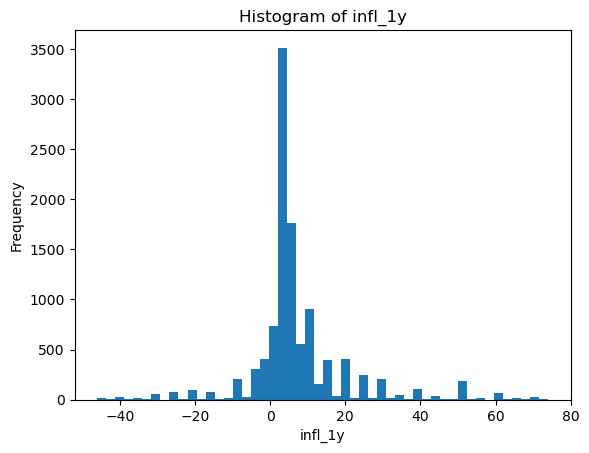

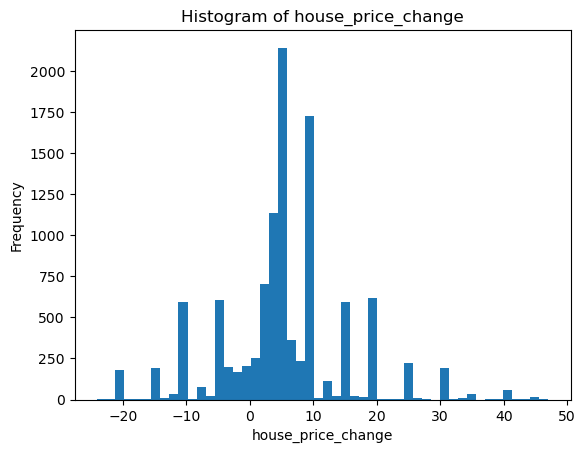

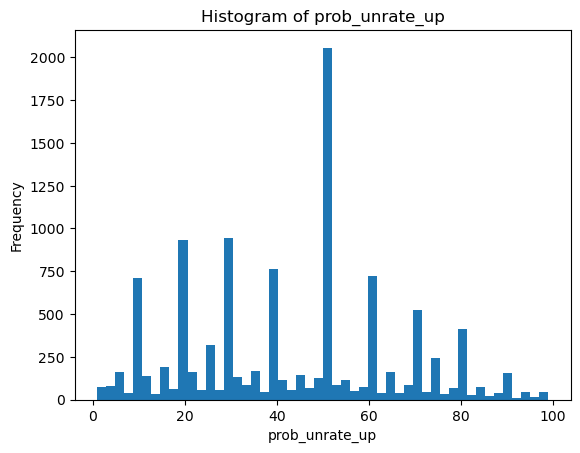

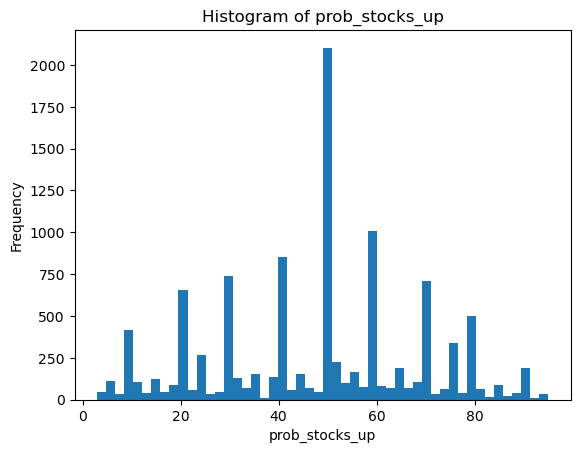

In [ ]:
# Plot histograms for each expectation variable
for var in expectation_vars:
    
    plt.figure()
    
    plt.hist(df[var], bins=50)
    
    plt.title(f"Histogram of {var}")
    plt.xlabel(var)
    plt.ylabel("Frequency")
    
    plt.show()

In [ ]:
# Create year-month variable
df["year_month"] = df["date"].dt.to_period("M")

In [ ]:
# Compute monthly averages
df_monthly_avg = (
    df.groupby("year_month")[expectation_vars]
    .mean()
    .reset_index()
)

# Convert back to timestamp for plotting
df_monthly_avg["year_month"] = df_monthly_avg["year_month"].dt.to_timestamp()

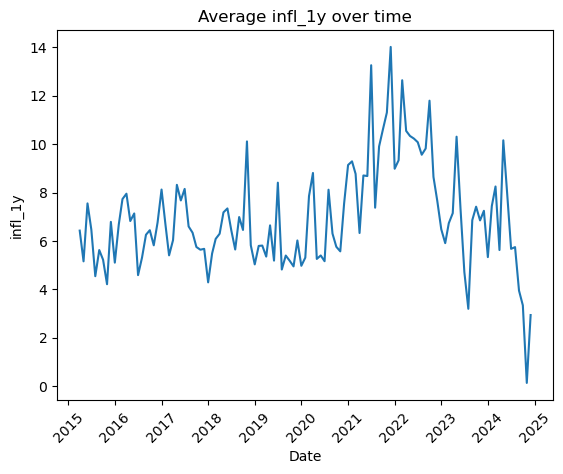

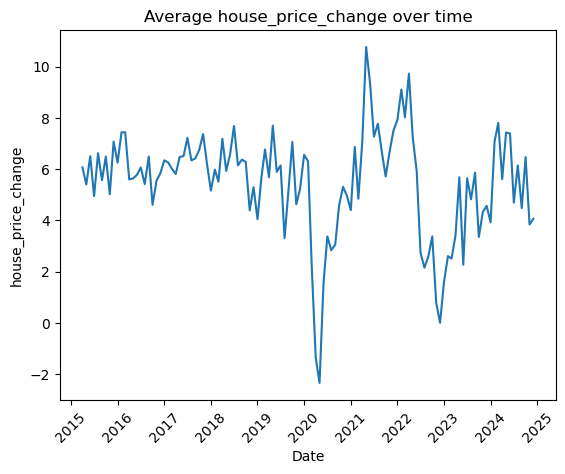

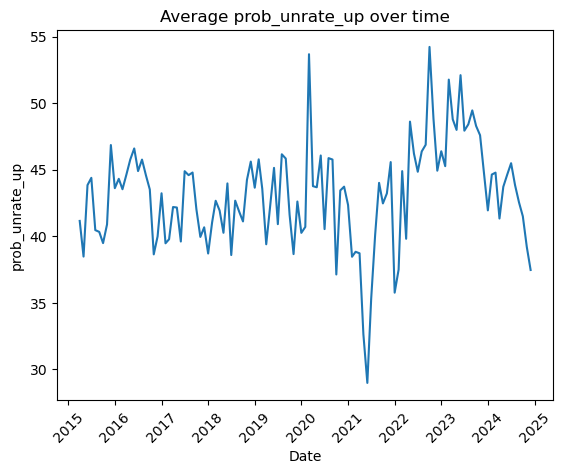

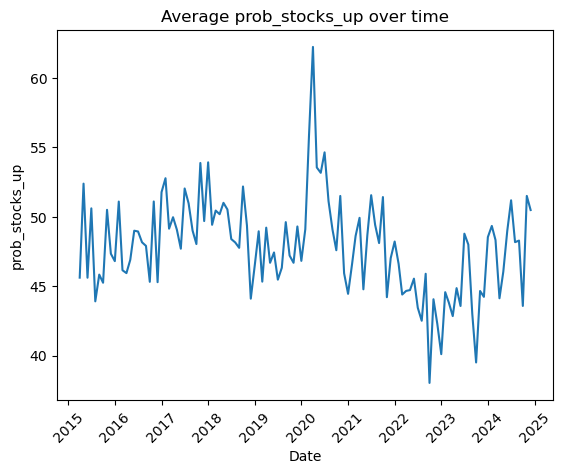

In [ ]:
# Plot time series for each expectation variable
for var in expectation_vars:
    
    plt.figure()
    
    plt.plot(df_monthly_avg["year_month"], df_monthly_avg[var])
    
    plt.title(f"Average {var} over time")
    plt.xlabel("Date")
    plt.ylabel(var)
    
    plt.xticks(rotation=45)
    
    plt.show()

In [ ]:
# Compute fraction of optimists per month
df_monthly_optimist = (
    df.groupby("year_month")[optimist_vars]
    .mean()
    .reset_index()
)

df_monthly_optimist["year_month"] = df_monthly_optimist["year_month"].dt.to_timestamp()

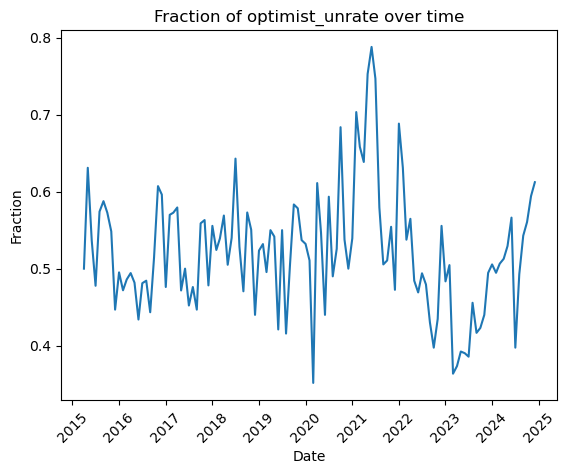

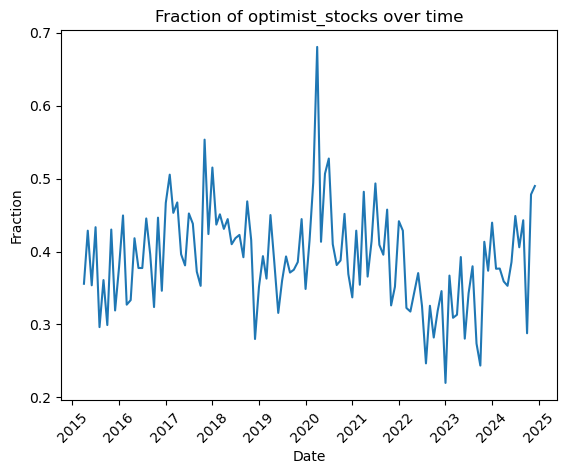

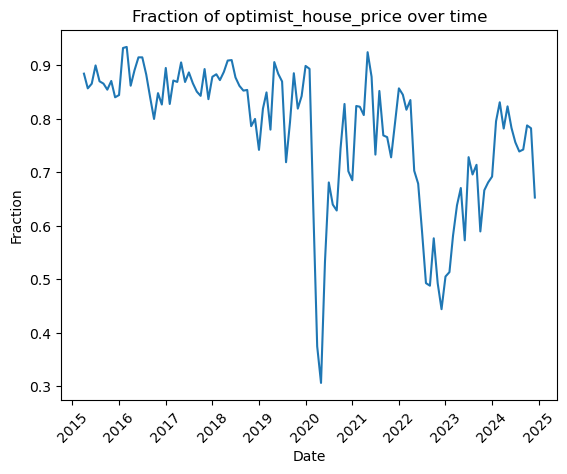

In [ ]:
# Plot fraction of optimists over time
for var in optimist_vars:
    
    plt.figure()
    
    plt.plot(df_monthly_optimist["year_month"], df_monthly_optimist[var])
    
    plt.title(f"Fraction of {var} over time")
    plt.xlabel("Date")
    plt.ylabel("Fraction")
    
    plt.xticks(rotation=45)
    
    plt.show()

## Discussion — Part 3

The histograms show that the expectation variables exhibit substantial heterogeneity across respondents. Inflation and house price expectations display dispersion, while probability-based expectations such as unemployment and stock market outcomes are bounded between 0 and 100.

The time series of average expectations reveal how beliefs evolve over time, likely reflecting changes in macroeconomic conditions such as inflation dynamics, labor market conditions, and financial market performance.

The fraction of optimistic respondents varies over time, indicating shifts in sentiment. For example, optimism about unemployment or stock markets may increase during economic expansions and decline during downturns.

These patterns suggest that both macroeconomic conditions and individual characteristics are important for explaining expectations.

# Part 4 — Exploratory data analysis (macro/finance)

In this part, I examine how the macroeconomic and financial variables evolve over the SCE sample period.

I create:
1. one figure with time series plots of the original macro/finance variables in levels,
2. one figure with time series plots of selected variables in absolute or relative differences,
3. correlation tables showing which macro/finance variables are most strongly associated with each expectations variable.

All plots are restricted to the survey period of the SCE.

In [ ]:
# Define macro variables in levels
macro_level_vars = [
    "oil",
    "sp500",
    "cpi",
    "fed_funds",
    "unrate",
    "dollar",
    "mortgage",
    "gdp",
    "house_price_index",
]

# Define a selected set of difference variables
# I keep a manageable subset so the figure stays readable
macro_diff_vars = [
    "oil_pct_12m",
    "sp500_pct_12m",
    "cpi_pct_12m",
    "unrate_chg_1m",
    "fed_funds_chg_1m",
    "gdp_pct_4q",
    "house_price_index_pct_4q",
]

# Restrict to SCE survey period
start_date = df["date"].min()
end_date = df["date"].max()

# Build unique monthly plotting dataset
monthly_plot_vars = [
    "oil", "sp500", "cpi", "fed_funds", "unrate", "dollar", "mortgage",
    "oil_pct_12m", "sp500_pct_12m", "cpi_pct_12m", "unrate_chg_1m", "fed_funds_chg_1m"
]

df_monthly_plot = (
    df.loc[(df["date"] >= start_date) & (df["date"] <= end_date),
           ["merge_date_monthly"] + monthly_plot_vars]
    .groupby("merge_date_monthly")
    .first()
    .reset_index()
    .sort_values("merge_date_monthly")
)

# Build unique quarterly plotting dataset
quarterly_plot_vars = [
    "gdp", "house_price_index", "gdp_pct_4q", "house_price_index_pct_4q"
]

df_quarterly_plot = (
    df.loc[(df["date"] >= start_date) & (df["date"] <= end_date),
           ["merge_date_quarterly"] + quarterly_plot_vars]
    .groupby("merge_date_quarterly")
    .first()
    .reset_index()
    .sort_values("merge_date_quarterly")
)

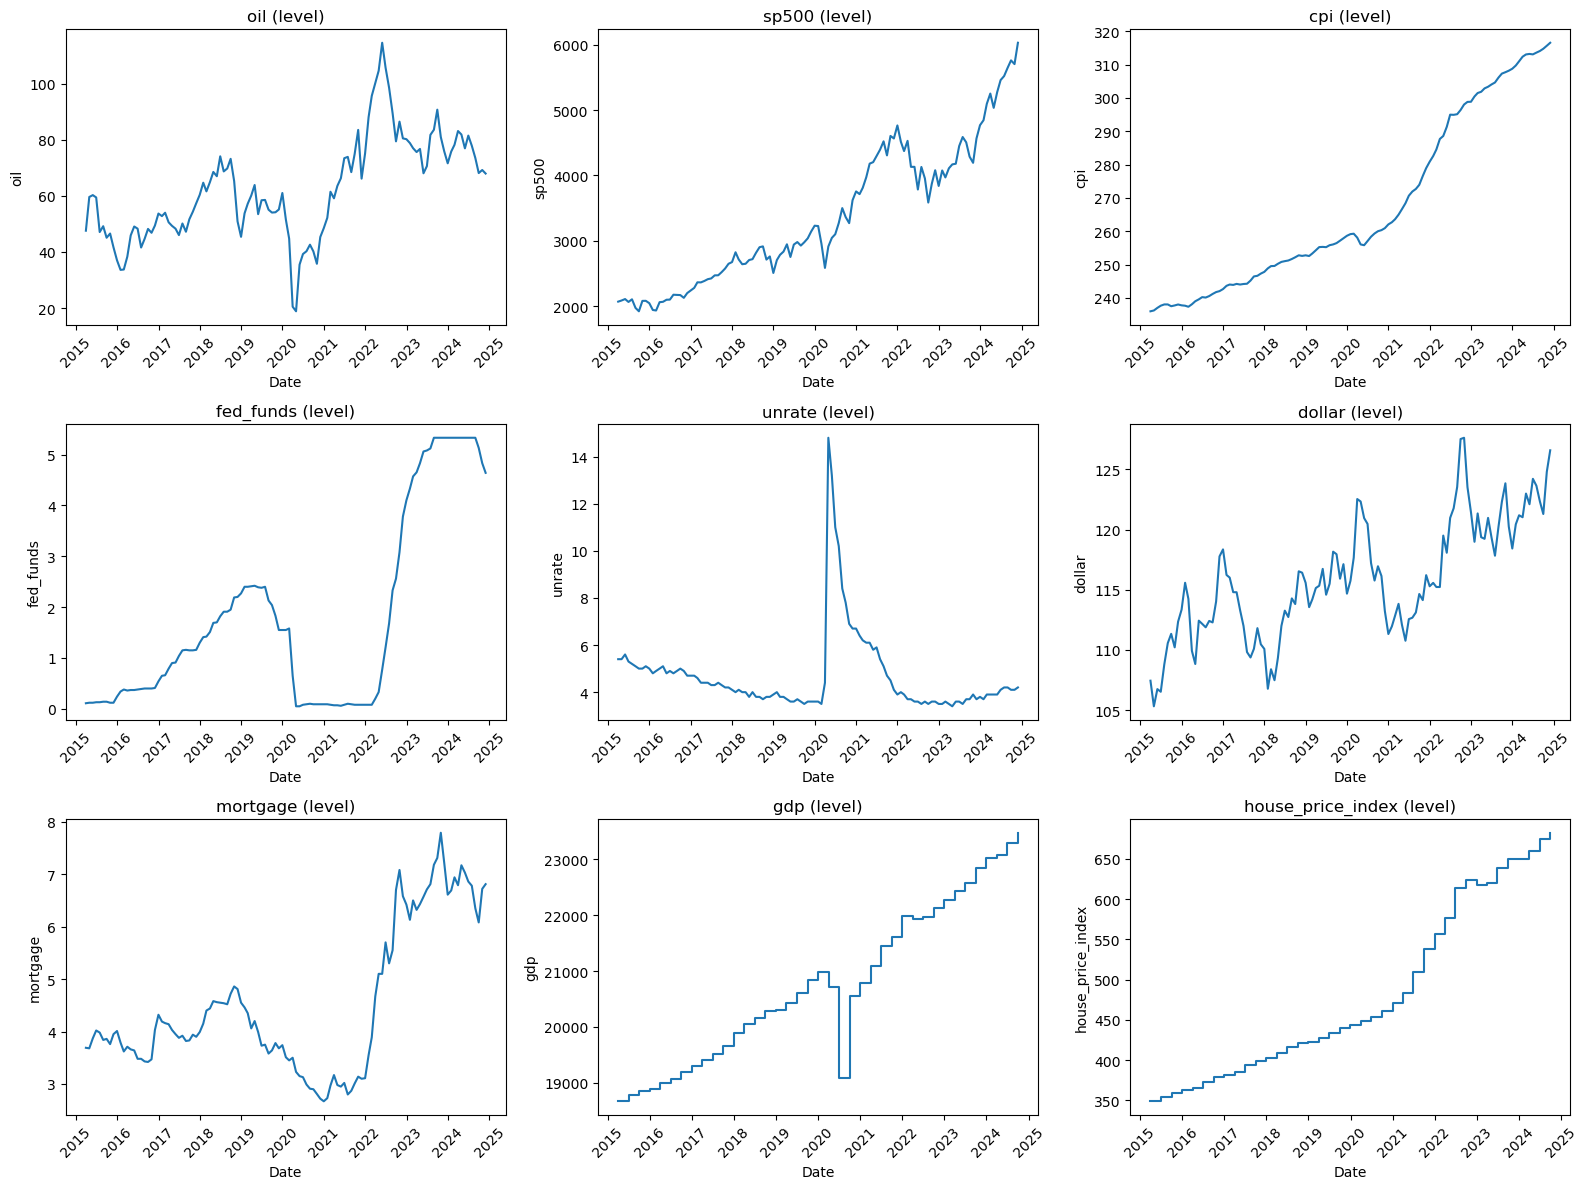

In [ ]:
# Create one figure with subplots for macro variables in levels
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(macro_level_vars):
    ax = axes[i]

    # Quarterly variables
    if var in ["gdp", "house_price_index"]:
        ax.step(df_quarterly_plot["merge_date_quarterly"], df_quarterly_plot[var], where="post")
        ax.set_xlabel("Date")
        ax.set_ylabel(var)
        ax.set_title(f"{var} (level)")
    # Monthly variables
    else:
        ax.plot(df_monthly_plot["merge_date_monthly"], df_monthly_plot[var])
        ax.set_xlabel("Date")
        ax.set_ylabel(var)
        ax.set_title(f"{var} (level)")

    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

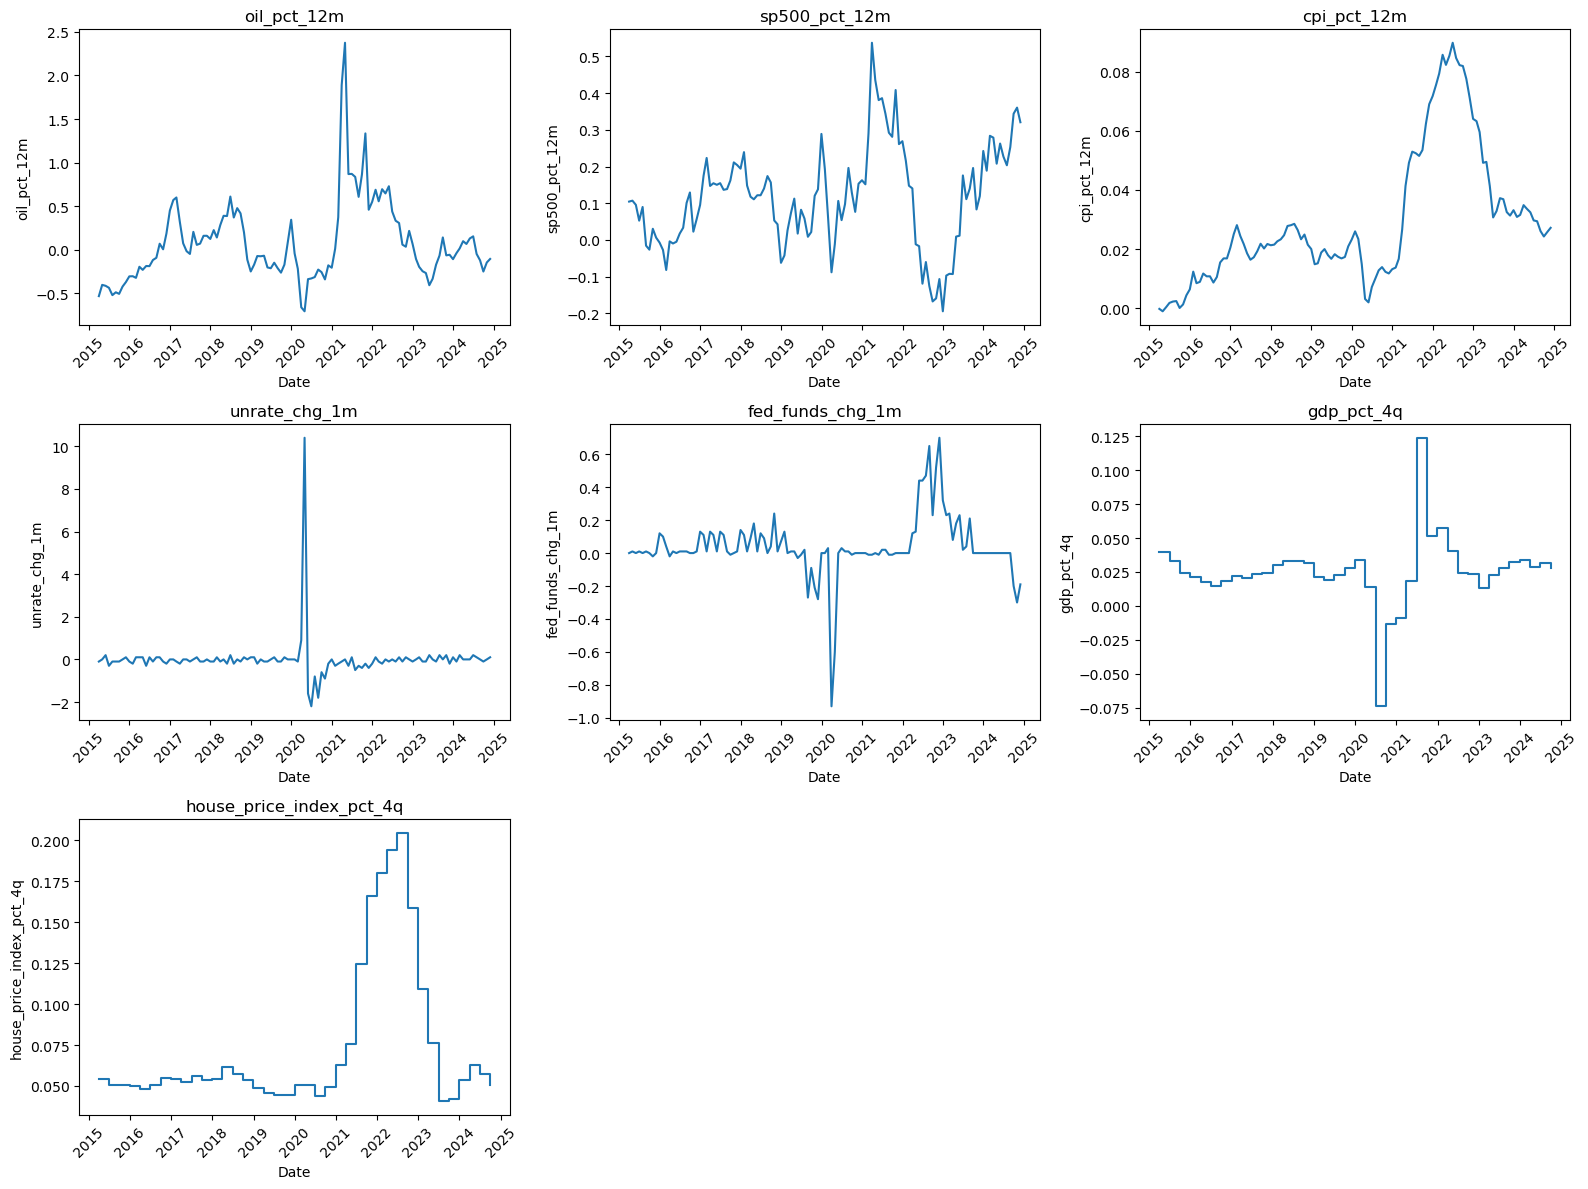

In [ ]:
# Create one figure with subplots for selected macro variables in differences
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, var in enumerate(macro_diff_vars):
    ax = axes[i]

    # Quarterly difference variables
    if var in ["gdp_pct_4q", "house_price_index_pct_4q"]:
        ax.step(df_quarterly_plot["merge_date_quarterly"], df_quarterly_plot[var], where="post")
        ax.set_xlabel("Date")
        ax.set_ylabel(var)
        ax.set_title(var)
    # Monthly difference variables
    else:
        ax.plot(df_monthly_plot["merge_date_monthly"], df_monthly_plot[var])
        ax.set_xlabel("Date")
        ax.set_ylabel(var)
        ax.set_title(var)

    ax.tick_params(axis="x", rotation=45)

# Hide unused subplot spaces
for j in range(len(macro_diff_vars), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# Expectations variables
expectation_vars = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up",
]

# Macro variables used in Part 4
macro_vars_for_corr = macro_level_vars + macro_diff_vars

In [ ]:
# Show only the 15 strongest correlations for each expectations variable
for target in expectation_vars:
    corr_table = (
        df[[target] + macro_vars_for_corr]
        .corr(numeric_only=True)[target]
        .drop(target)
        .sort_values(key=lambda x: x.abs(), ascending=False)
        .head(15)
        .to_frame(name="correlation")
    )

    print(f"\nTop correlations with {target}:\n")
    display(corr_table)


Top correlations with infl_1y:



,correlation
house_price_index_pct_4q,0.103130
cpi_pct_12m,0.092920
oil_pct_12m,0.067052
oil,0.062116
fed_funds_chg_1m,0.040284
gdp_pct_4q,0.040154
sp500,0.039738
house_price_index,0.035334
gdp,0.033497
cpi,0.031752



Top correlations with house_price_change:



,correlation
sp500_pct_12m,0.099922
dollar,-0.094739
oil_pct_12m,0.088132
gdp_pct_4q,0.066579
unrate_chg_1m,-0.055793
mortgage,-0.050853
unrate,-0.050097
fed_funds,-0.048065
house_price_index,-0.045946
cpi,-0.043716



Top correlations with prob_unrate_up:



,correlation
sp500_pct_12m,-0.091569
mortgage,0.074819
dollar,0.068480
fed_funds,0.065421
oil_pct_12m,-0.063655
cpi,0.049589
house_price_index,0.048932
fed_funds_chg_1m,0.044303
gdp,0.036446
cpi_pct_12m,0.029861



Top correlations with prob_stocks_up:



,correlation
oil,-0.072122
fed_funds_chg_1m,-0.069188
cpi_pct_12m,-0.065837
mortgage,-0.062177
cpi,-0.059562
house_price_index,-0.059339
house_price_index_pct_4q,-0.053841
gdp,-0.051598
unrate,0.049394
fed_funds,-0.046864


## Discussion — Part 4

The first figure shows the evolution of the macroeconomic and financial variables in levels over the SCE sample period. Real activity variables such as GDP and house prices follow smoother long-run trends, while financial variables such as oil prices and the S&P 500 display more short-run volatility.

The second figure focuses on selected difference variables. These series highlight periods of sharp macroeconomic and financial adjustment, such as the disruptions around 2020 and the subsequent recovery. Since households may react more strongly to recent changes than to levels, these transformed variables may be useful predictors in later parts of the analysis.

The correlation tables provide a first descriptive indication of which macro/finance variables are most closely associated with each expectations variable. These relationships are only descriptive, but they help motivate which predictors may be informative in the modeling stage.

# Part 5 — Predicting continuous expectation variables

In this part, I predict the four continuous expectations variables:
- `infl_1y`
- `house_price_change`
- `prob_unrate_up`
- `prob_stocks_up`

I perform the analysis in two steps:

1. **Step 1:** Use only macro/finance variables as predictors.
2. **Step 2:** Add a small set of individual-level SCE variables.

For each target variable, I estimate:
- Linear Regression
- Ridge Regression
- Lasso Regression

For Ridge and Lasso, I use time-series cross-validation to select the penalty parameter and plot validation curves.

To keep runtime manageable, I follow the performance advice in the assignment:
- I use 3-fold time-series cross-validation,
- I use a smaller grid of penalty values,
- I use only a limited number of additional SCE variables,
- and I optionally use a subsample while developing the code.

In [ ]:
# Import packages used in Part 5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, validation_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
# =========================
# Part 5 setup
# =========================

# Targets to predict
targets = [
    "infl_1y",
    "house_price_change",
    "prob_unrate_up",
    "prob_stocks_up",
]

# Macro features from Part 2
macro_features = [
    "oil_pct_12m",
    "sp500_pct_12m",
    "cpi_pct_12m",
    "unrate_chg_1m",
    "fed_funds_chg_1m",
    "gdp_pct_4q",
    "house_price_index_pct_4q",
]

# Performance settings
# Use fewer folds and fewer alpha values to reduce runtime
tscv = TimeSeriesSplit(n_splits=3)
alphas = np.logspace(-2, 2, 8)

# Set to True while developing if runtime is an issue
USE_DEV_SAMPLE = True
DEV_SAMPLE_FRAC = 0.30

In [ ]:
# Create a simple numerical literacy score from the individual literacy questions
numeracy_vars = [
    "num_lit_q1_correct",
    "num_lit_q2_correct",
    "num_lit_q3_correct",
    "num_lit_q5_correct",
    "num_lit_q6_correct",
    "num_lit_q8_correct",
    "num_lit_q9_correct",
]

df["numeracy_score"] = df[numeracy_vars].sum(axis=1)

In [ ]:
# =========================
# Step 1: Macro only
# =========================

# Time-based split required by the assignment
train_step1 = df[df["date"] < "2024-01-01"].copy()
test_step1 = df[
    (df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")
].copy()

print("Step 1 training observations:", len(train_step1))
print("Step 1 test observations:", len(test_step1))

Step 1 training observations: 9910
Step 1 test observations: 908


In [ ]:
# =========================
# Step 2: Macro + selected SCE variables
# =========================

# Keep this deliberately small.
# The assignment explicitly warns against using too many variables.
sce_extra_features = [
    "age_init",
    "female",
    "educ",
    "hh_inc_bin",
    "numeracy_score",
]

# These are categorical and should be dummy-encoded
categorical_vars = [
    "educ",
    "hh_inc_bin",
]

In [ ]:
# Work on a copy of the main dataset
df_step2 = df.copy()

# Optional development subsample for speed
# This is allowed by the assignment while implementing/debugging
if USE_DEV_SAMPLE:
    df_step2 = df_step2.sample(frac=DEV_SAMPLE_FRAC, random_state=42)

# Convert selected categorical variables to dummies
df_step2 = pd.get_dummies(
    df_step2,
    columns=categorical_vars,
    drop_first=True
)

# Rebuild the Step 2 feature list after dummy encoding
extended_features = macro_features.copy()

for var in sce_extra_features:
    if var in categorical_vars:
        dummy_cols = [col for col in df_step2.columns if col.startswith(f"{var}_")]
        extended_features.extend(dummy_cols)
    else:
        extended_features.append(var)

# Remove duplicates just in case
extended_features = list(dict.fromkeys(extended_features))

print("Step 2 number of features:", len(extended_features))
print("Step 2 features:")
print(extended_features)

Step 2 number of features: 24
Step 2 features:
['oil_pct_12m', 'sp500_pct_12m', 'cpi_pct_12m', 'unrate_chg_1m', 'fed_funds_chg_1m', 'gdp_pct_4q', 'house_price_index_pct_4q', 'age_init', 'female', 'educ_2.0', 'educ_3.0', 'educ_4.0', 'hh_inc_bin_rank', 'hh_inc_bin_2.0', 'hh_inc_bin_3.0', 'hh_inc_bin_4.0', 'hh_inc_bin_5.0', 'hh_inc_bin_6.0', 'hh_inc_bin_7.0', 'hh_inc_bin_8.0', 'hh_inc_bin_9.0', 'hh_inc_bin_10.0', 'hh_inc_bin_11.0', 'numeracy_score']


In [ ]:
# Time-based split for Step 2
train_step2 = df_step2[df_step2["date"] < "2024-01-01"].copy()
test_step2 = df_step2[
    (df_step2["date"] >= "2024-01-01") & (df_step2["date"] <= "2024-12-31")
].copy()

print("Step 2 training observations:", len(train_step2))
print("Step 2 test observations:", len(test_step2))

Step 2 training observations: 2990
Step 2 test observations: 255


In [ ]:
def fit_models_for_target(train_df, test_df, feature_list, target_name):
    """
    Fit OLS, Ridge, and Lasso for one target variable.
    Return all outputs needed for later plotting and comparison.
    """

    # Define X and y
    X_train = train_df[feature_list]
    y_train = train_df[target_name]

    X_test = test_df[feature_list]
    y_test = test_df[target_name]

    # -------------------------
    # 1. OLS
    # -------------------------
    ols = LinearRegression()
    ols.fit(X_train, y_train)
    y_pred_ols = ols.predict(X_test)

    rmse_ols = np.sqrt(mean_squared_error(y_test, y_pred_ols))
    r2_ols = r2_score(y_test, y_pred_ols)

    # -------------------------
    # 2. Ridge
    # -------------------------
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge())
    ])

    train_scores_ridge, val_scores_ridge = validation_curve(
        ridge_pipe,
        X_train,
        y_train,
        param_name="model__alpha",
        param_range=alphas,
        cv=tscv,
        scoring="neg_mean_squared_error",
    )

    train_rmse_ridge = np.sqrt(-train_scores_ridge.mean(axis=1))
    val_rmse_ridge = np.sqrt(-val_scores_ridge.mean(axis=1))
    best_alpha_ridge = alphas[np.argmin(val_rmse_ridge)]

    ridge_best = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=best_alpha_ridge))
    ])
    ridge_best.fit(X_train, y_train)
    y_pred_ridge = ridge_best.predict(X_test)

    rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
    r2_ridge = r2_score(y_test, y_pred_ridge)

    # -------------------------
    # 3. Lasso
    # -------------------------
    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(max_iter=10000))
    ])

    train_scores_lasso, val_scores_lasso = validation_curve(
        lasso_pipe,
        X_train,
        y_train,
        param_name="model__alpha",
        param_range=alphas,
        cv=tscv,
        scoring="neg_mean_squared_error",
    )

    train_rmse_lasso = np.sqrt(-train_scores_lasso.mean(axis=1))
    val_rmse_lasso = np.sqrt(-val_scores_lasso.mean(axis=1))
    best_alpha_lasso = alphas[np.argmin(val_rmse_lasso)]

    lasso_best = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=best_alpha_lasso, max_iter=10000))
    ])
    lasso_best.fit(X_train, y_train)
    y_pred_lasso = lasso_best.predict(X_test)

    rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    r2_lasso = r2_score(y_test, y_pred_lasso)

    # Build monthly average actual series
    actual_df = pd.concat([
        train_df[["date", target_name]],
        test_df[["date", target_name]],
    ], axis=0).copy()
    
    actual_df["year_month"] = actual_df["date"].dt.to_period("M")
    actual_avg = (
        actual_df.groupby("year_month")[target_name]
        .mean()
        .reset_index()
    )
    actual_avg["year_month"] = actual_avg["year_month"].dt.to_timestamp()
    
    # Build monthly average predicted series
    pred_df = pd.concat([
        pd.DataFrame({
            "date": train_df["date"],
            "pred": ridge_best.predict(X_train)
        }),
        pd.DataFrame({
            "date": test_df["date"],
            "pred": y_pred_ridge
        }),
    ], axis=0).copy()
    
    pred_df["year_month"] = pred_df["date"].dt.to_period("M")
    pred_avg = (
        pred_df.groupby("year_month")["pred"]
        .mean()
        .reset_index()
    )
    pred_avg["year_month"] = pred_avg["year_month"].dt.to_timestamp()

    return {
        "ridge_train_rmse_curve": train_rmse_ridge,
        "ridge_val_rmse_curve": val_rmse_ridge,
        "lasso_train_rmse_curve": train_rmse_lasso,
        "lasso_val_rmse_curve": val_rmse_lasso,
        "actual_avg": actual_avg,
        "pred_avg": pred_avg,
        "rmse": {
            "OLS": rmse_ols,
            "Ridge": rmse_ridge,
            "Lasso": rmse_lasso,
        },
        "r2": {
            "OLS": r2_ols,
            "Ridge": r2_ridge,
            "Lasso": r2_lasso,
        },
        "best_alpha_ridge": best_alpha_ridge,
        "best_alpha_lasso": best_alpha_lasso,
    }

In [ ]:
# Fit Step 1 models and store results
results_step1 = {}

for target in targets:
    results_step1[target] = fit_models_for_target(
        train_df=train_step1,
        test_df=test_step1,
        feature_list=macro_features,
        target_name=target,
    )

print("Step 1 finished.")

Step 1 finished.


In [ ]:
# Fit Step 2 models and store results
results_step2 = {}

for target in targets:
    results_step2[target] = fit_models_for_target(
        train_df=train_step2,
        test_df=test_step2,
        feature_list=extended_features,
        target_name=target,
    )

print("Step 2 finished.")

Step 2 finished.


In [ ]:
# Print concise summary for both steps
for target in targets:
    print("\n==========================================")
    print(f"Target: {target}")
    print("==========================================")

    print("\nStep 1: Macro only")
    print("Best Ridge alpha:", results_step1[target]["best_alpha_ridge"])
    print("Best Lasso alpha:", results_step1[target]["best_alpha_lasso"])
    print("RMSE:", results_step1[target]["rmse"])
    print("R²:", results_step1[target]["r2"])

    print("\nStep 2: Macro + SCE")
    print("Best Ridge alpha:", results_step2[target]["best_alpha_ridge"])
    print("Best Lasso alpha:", results_step2[target]["best_alpha_lasso"])
    print("RMSE:", results_step2[target]["rmse"])
    print("R²:", results_step2[target]["r2"])


Target: infl_1y

Step 1: Macro only
Best Ridge alpha: 100.0
Best Lasso alpha: 0.517947467923121
RMSE: {'OLS': np.float64(15.084946186979554), 'Ridge': np.float64(15.084557403128354), 'Lasso': np.float64(15.035903195480818)}
R²: {'OLS': -0.009101560323206082, 'Ridge': -0.009049545906932188, 'Lasso': -0.002550802942411945}

Step 2: Macro + SCE
Best Ridge alpha: 100.0
Best Lasso alpha: 0.517947467923121
RMSE: {'OLS': np.float64(14.57910695158302), 'Ridge': np.float64(14.608726655413848), 'Lasso': np.float64(14.60616319246947)}
R²: {'OLS': 0.07360287918612696, 'Ridge': 0.06983481817426995, 'Lasso': 0.07016123057517543}

Target: house_price_change

Step 1: Macro only
Best Ridge alpha: 26.826957952797247
Best Lasso alpha: 1.9306977288832496
RMSE: {'OLS': np.float64(10.350325715209532), 'Ridge': np.float64(10.350252970335708), 'Lasso': np.float64(10.35362110465196)}
R²: {'OLS': -0.00022427778578881785, 'Ridge': -0.00021021814453803245, 'Lasso': -0.0008612921822204189}

Step 2: Macro + SCE
Be

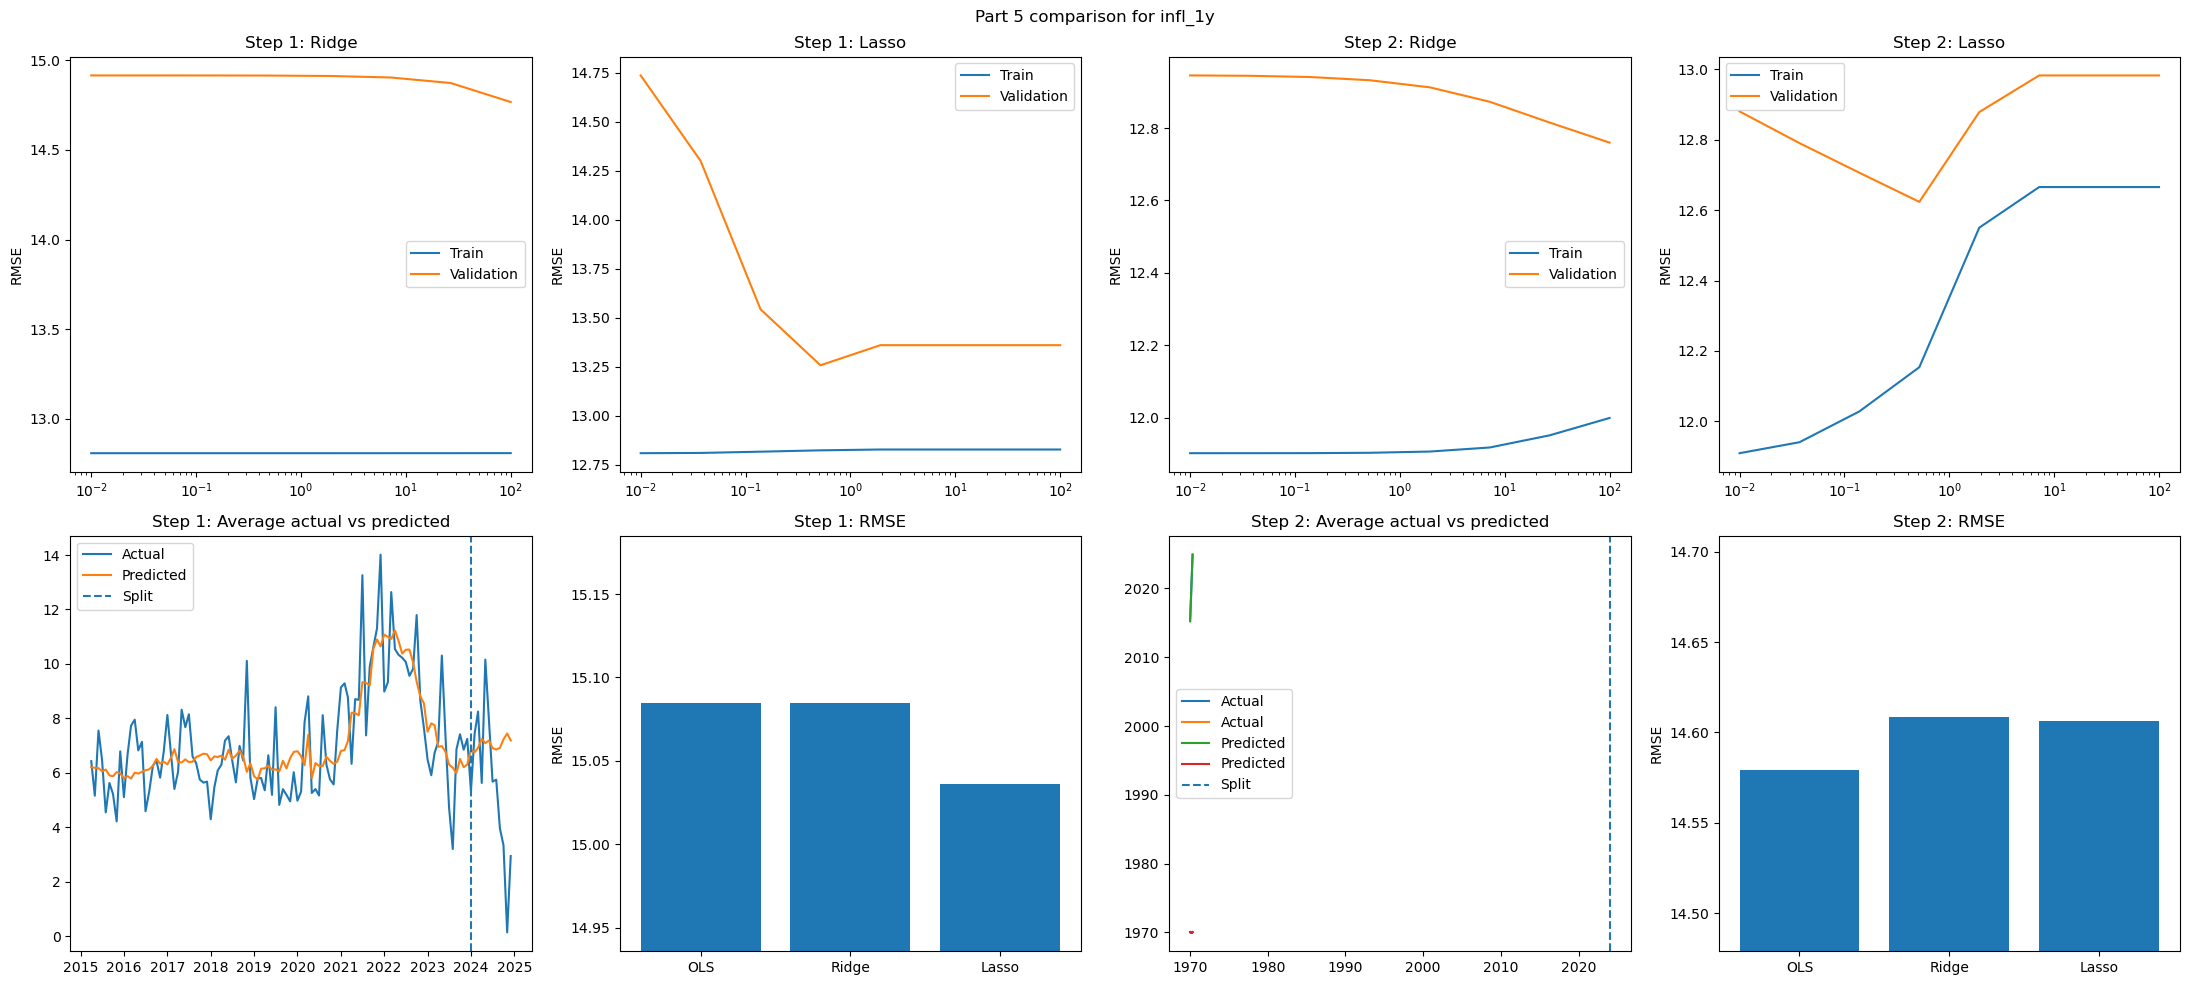

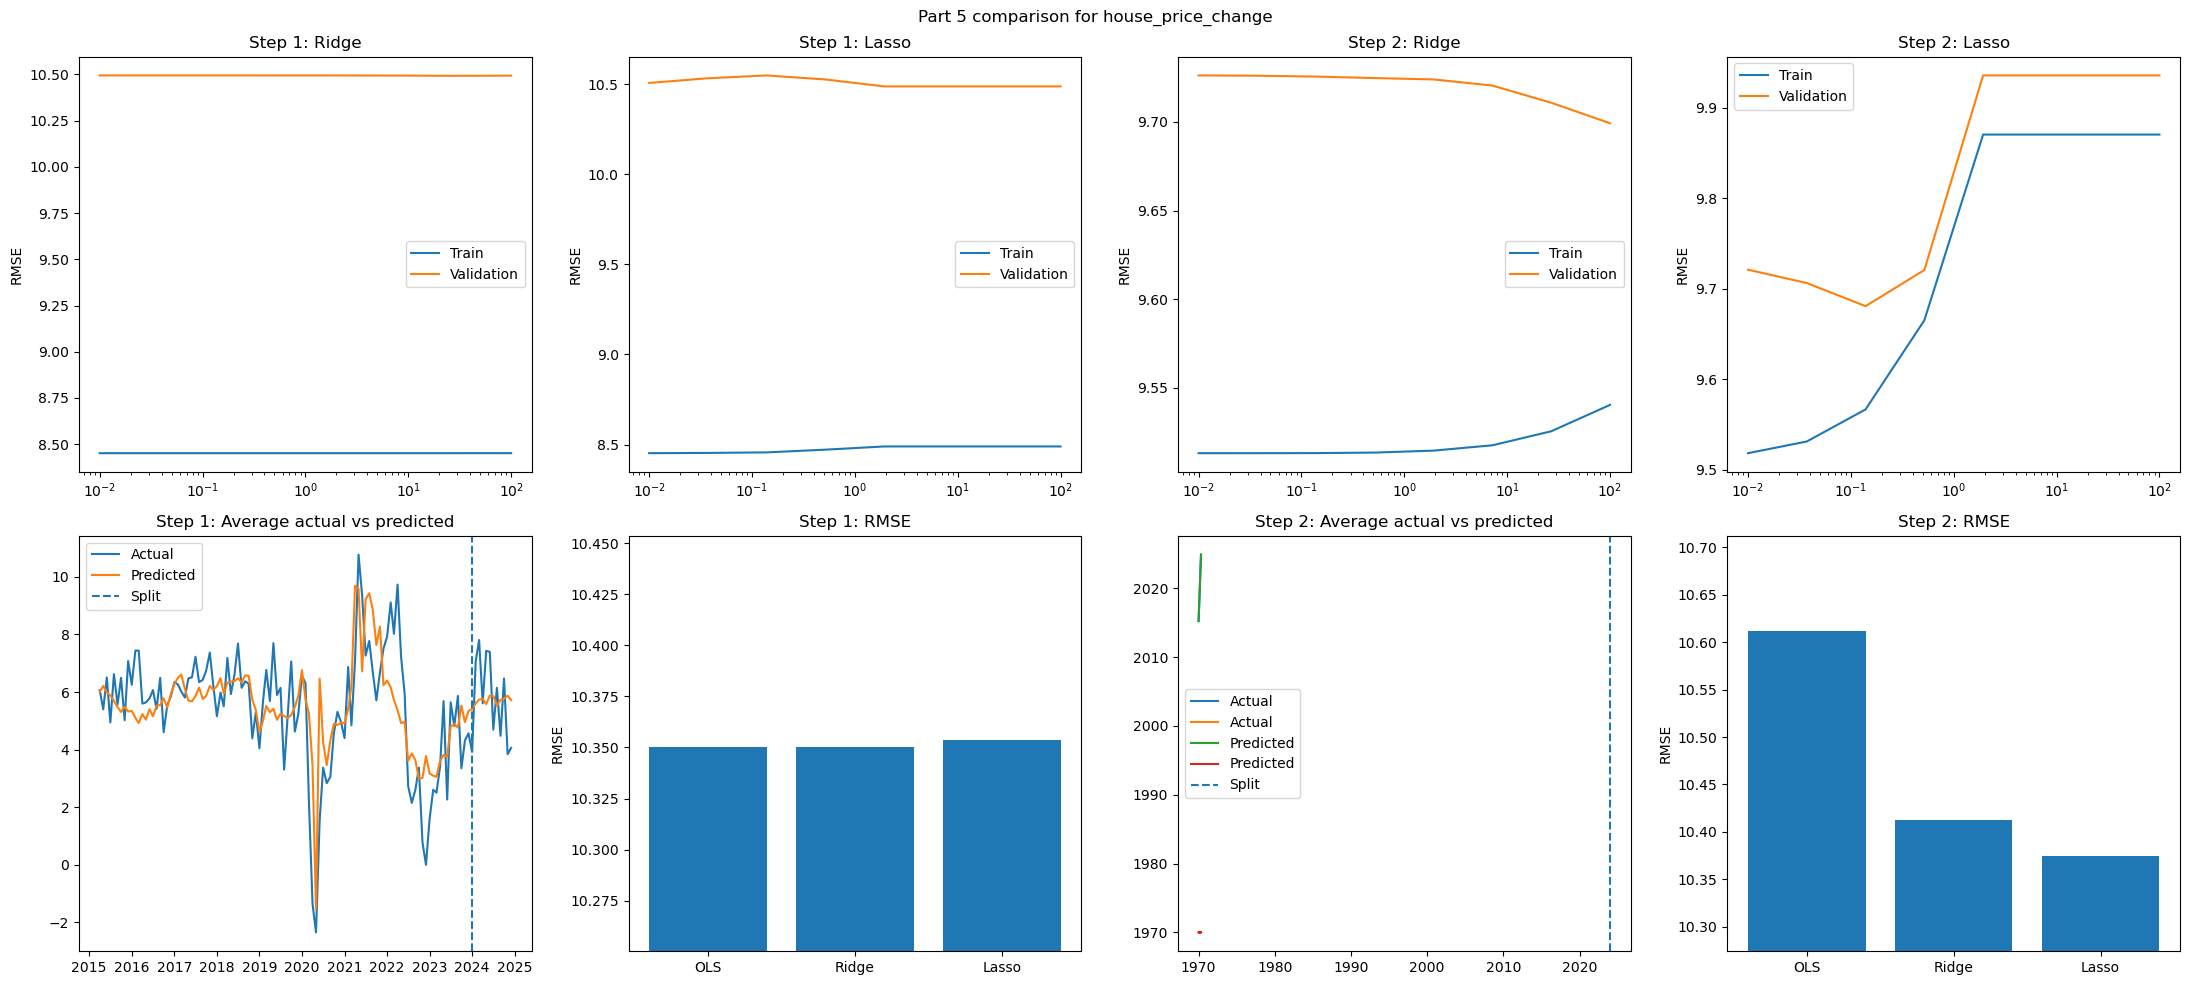

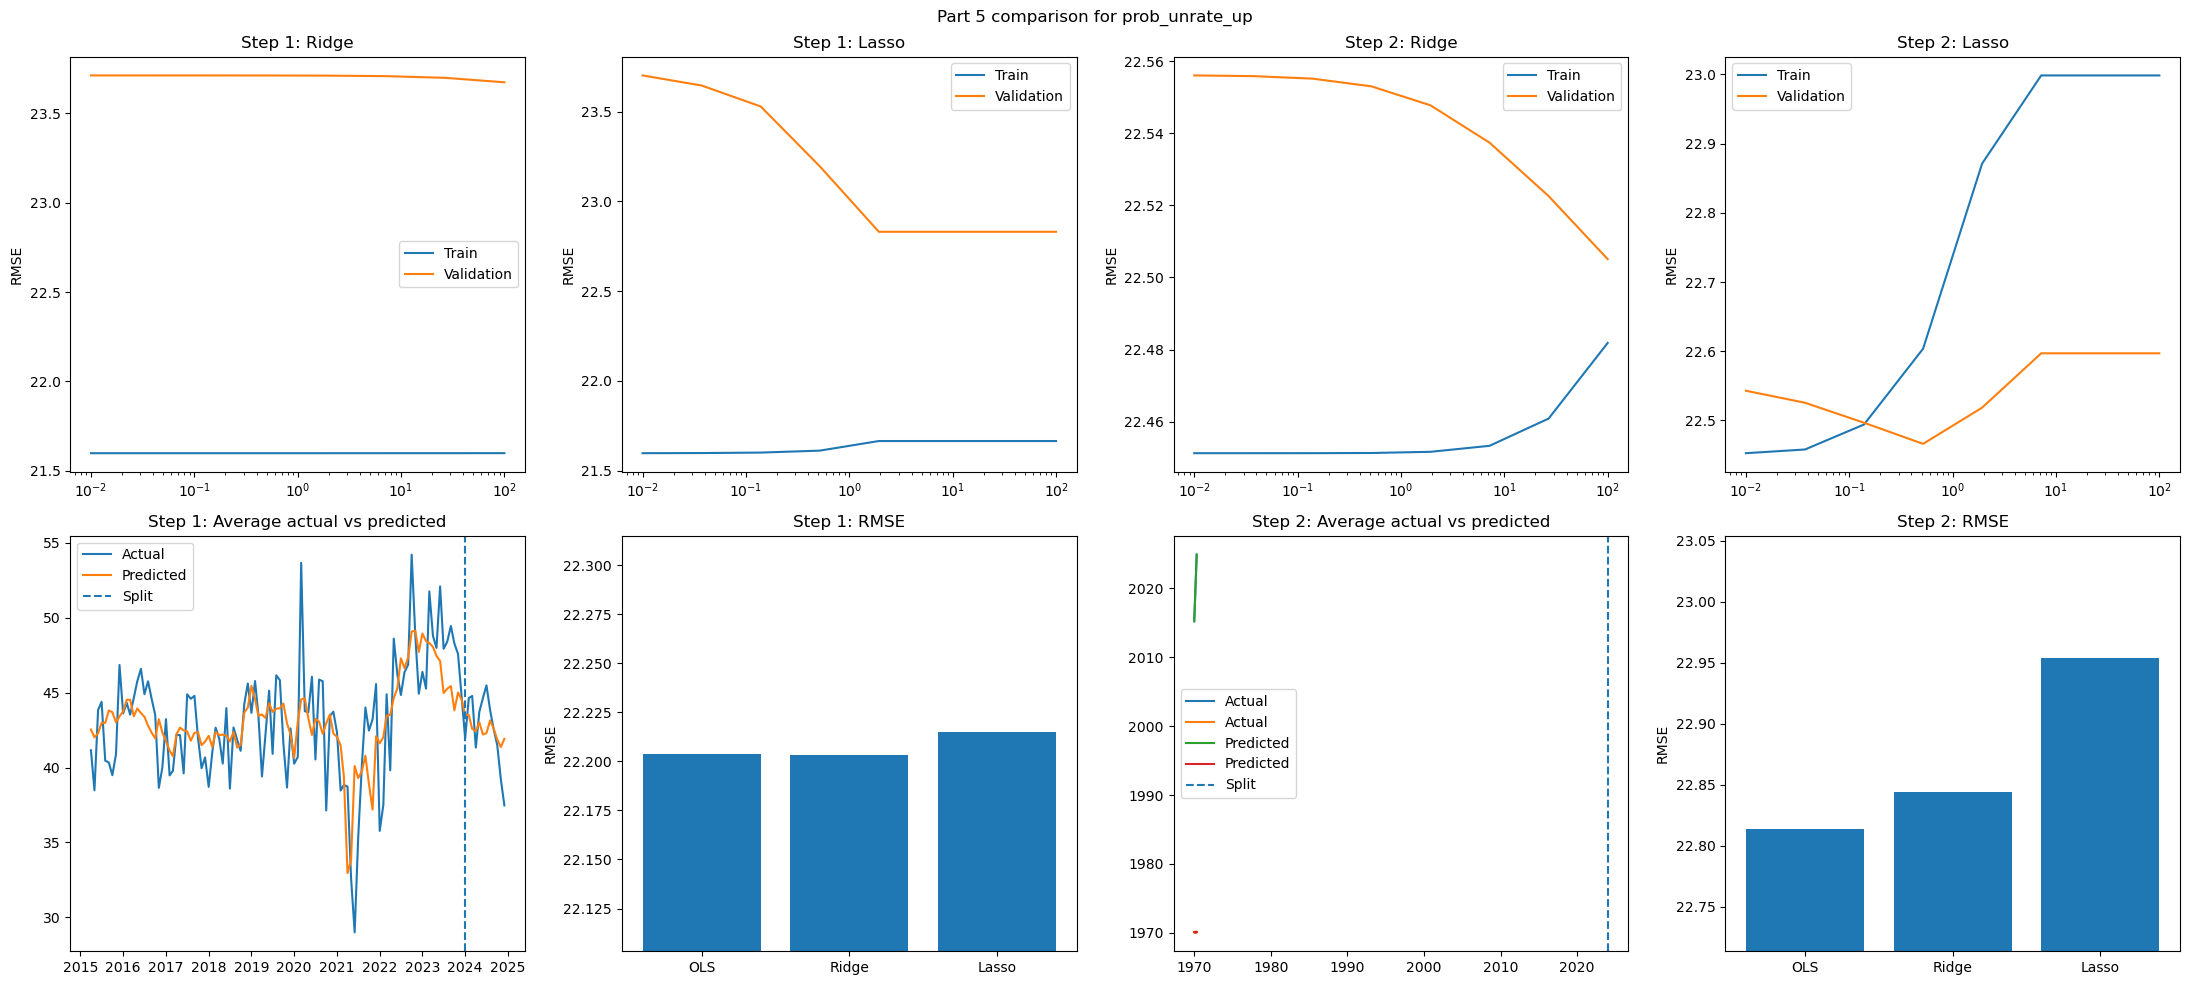

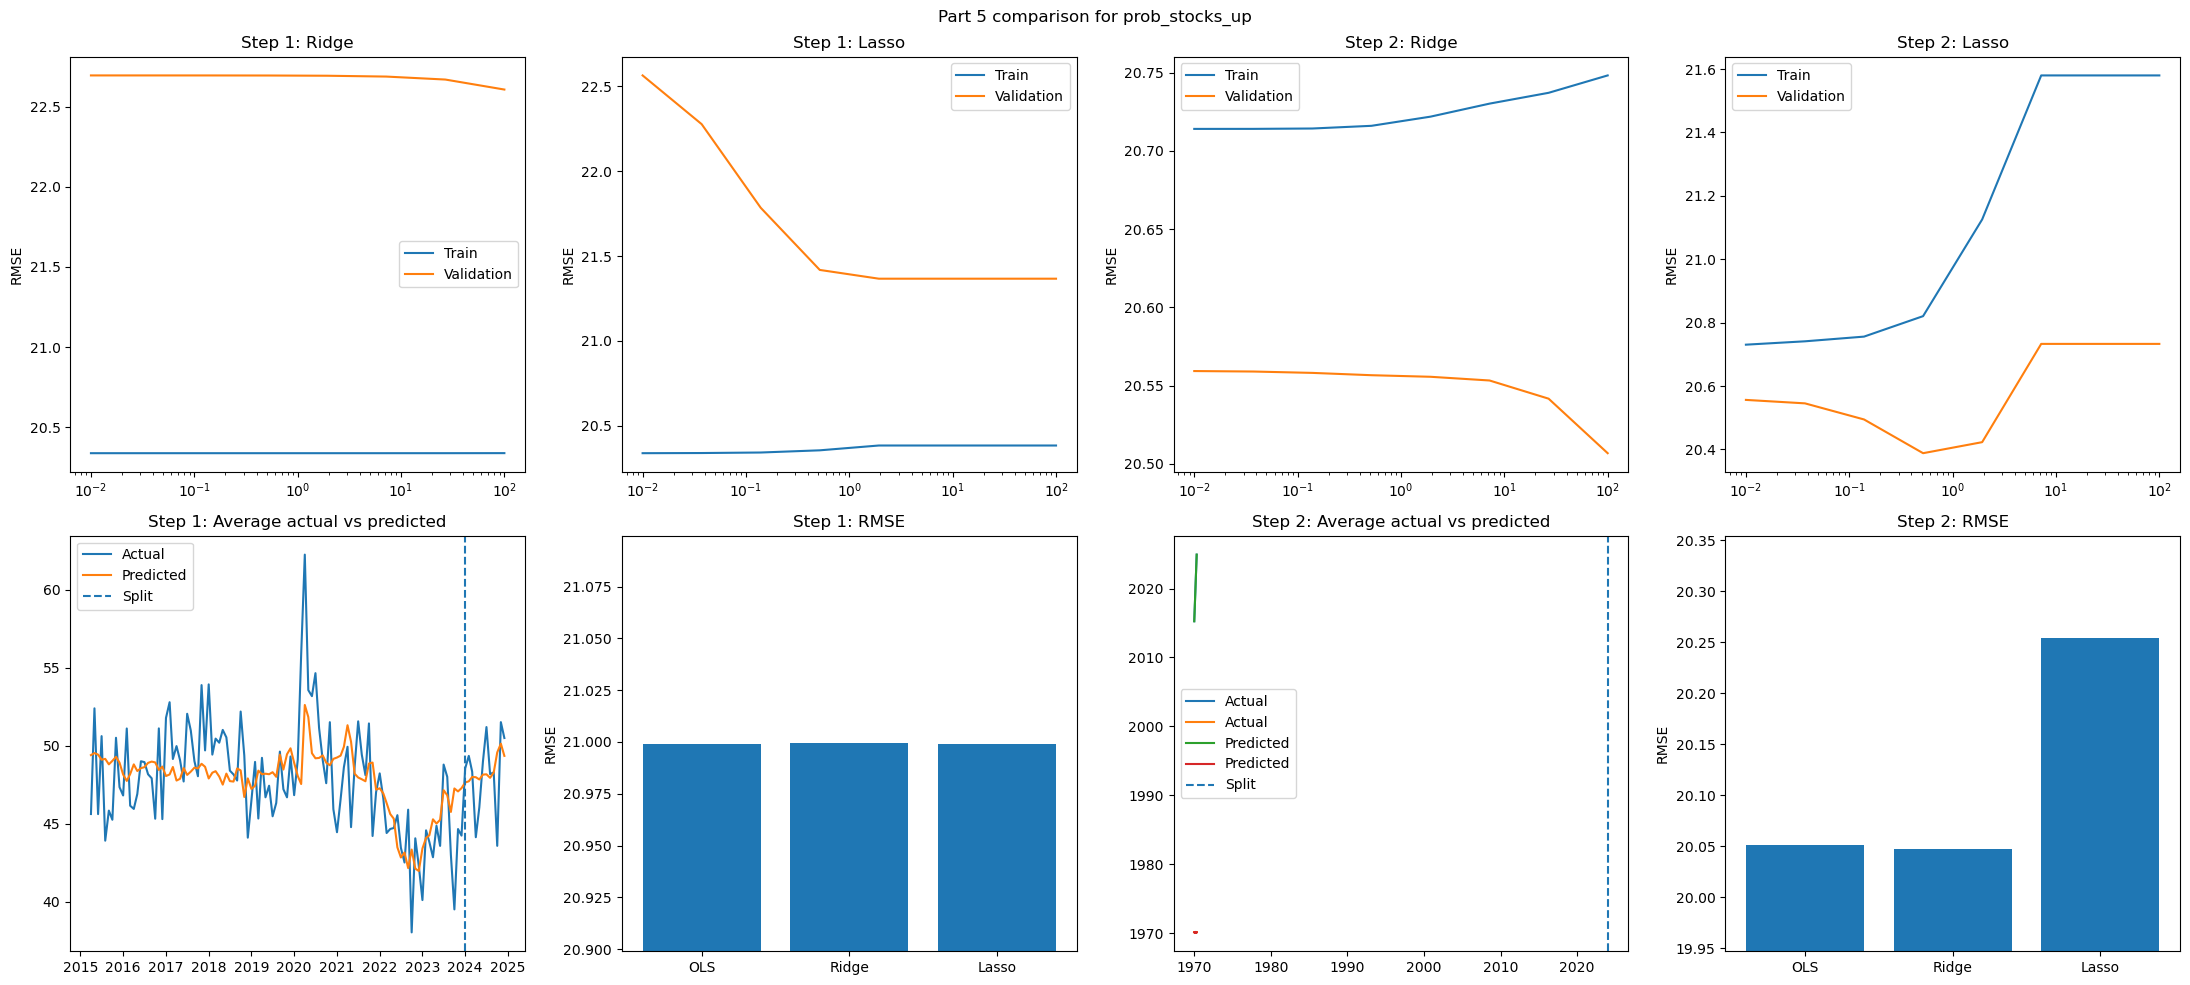

In [ ]:
# Create one 2x4 figure per target:
# left half = Step 1, right half = Step 2

for target in targets:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    # -------------------------
    # Top row: validation curves
    # -------------------------

    # Step 1 Ridge
    axes[0, 0].plot(alphas, results_step1[target]["ridge_train_rmse_curve"], label="Train")
    axes[0, 0].plot(alphas, results_step1[target]["ridge_val_rmse_curve"], label="Validation")
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_title("Step 1: Ridge")
    axes[0, 0].set_ylabel("RMSE")
    axes[0, 0].legend()

    # Step 1 Lasso
    axes[0, 1].plot(alphas, results_step1[target]["lasso_train_rmse_curve"], label="Train")
    axes[0, 1].plot(alphas, results_step1[target]["lasso_val_rmse_curve"], label="Validation")
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_title("Step 1: Lasso")
    axes[0, 1].set_ylabel("RMSE")
    axes[0, 1].legend()

    # Step 2 Ridge
    axes[0, 2].plot(alphas, results_step2[target]["ridge_train_rmse_curve"], label="Train")
    axes[0, 2].plot(alphas, results_step2[target]["ridge_val_rmse_curve"], label="Validation")
    axes[0, 2].set_xscale("log")
    axes[0, 2].set_title("Step 2: Ridge")
    axes[0, 2].set_ylabel("RMSE")
    axes[0, 2].legend()

    # Step 2 Lasso
    axes[0, 3].plot(alphas, results_step2[target]["lasso_train_rmse_curve"], label="Train")
    axes[0, 3].plot(alphas, results_step2[target]["lasso_val_rmse_curve"], label="Validation")
    axes[0, 3].set_xscale("log")
    axes[0, 3].set_title("Step 2: Lasso")
    axes[0, 3].set_ylabel("RMSE")
    axes[0, 3].legend()

    # -------------------------
    # Bottom row: fit + RMSE
    # -------------------------

    axes[1, 0].plot(
        results_step1[target]["actual_avg"]["year_month"],
        results_step1[target]["actual_avg"][target],
        label="Actual"
    )
    axes[1, 0].plot(
        results_step1[target]["pred_avg"]["year_month"],
        results_step1[target]["pred_avg"]["pred"],
        label="Predicted"
    )
    axes[1, 0].axvline(pd.Timestamp("2024-01-01"), linestyle="--", label="Split")
    axes[1, 0].set_title("Step 1: Average actual vs predicted")
    axes[1, 0].legend()

    # Step 1 RMSE
    axes[1, 1].bar(
        list(results_step1[target]["rmse"].keys()),
        list(results_step1[target]["rmse"].values())
    )
    axes[1, 1].set_title("Step 1: RMSE")
    axes[1, 1].set_ylabel("RMSE")
    step1_rmse_vals = list(results_step1[target]["rmse"].values())
    axes[1, 1].set_ylim(min(step1_rmse_vals) - 0.1, max(step1_rmse_vals) + 0.1)

    # Step 2 actual vs predicted
    axes[1, 2].plot(
        results_step2[target]["actual_avg"].index,
        results_step2[target]["actual_avg"].values,
        label="Actual"
    )
    axes[1, 2].plot(
        results_step2[target]["pred_avg"].index,
        results_step2[target]["pred_avg"].values,
        label="Predicted"
    )
    axes[1, 2].axvline(pd.Timestamp("2024-01-01"), linestyle="--", label="Split")
    axes[1, 2].set_title("Step 2: Average actual vs predicted")
    axes[1, 2].legend()

    # Step 2 RMSE
    axes[1, 3].bar(
        list(results_step2[target]["rmse"].keys()),
        list(results_step2[target]["rmse"].values())
    )
    axes[1, 3].set_title("Step 2: RMSE")
    axes[1, 3].set_ylabel("RMSE")
    step2_rmse_vals = list(results_step2[target]["rmse"].values())
    axes[1, 3].set_ylim(min(step2_rmse_vals) - 0.1, max(step2_rmse_vals) + 0.1)

    plt.suptitle(f"Part 5 comparison for {target}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Build a neat comparison table for RMSE and R²
comparison_rows = []

for target in targets:
    for model_name in ["OLS", "Ridge", "Lasso"]:
        comparison_rows.append({
            "target": target,
            "model": model_name,
            "step1_rmse": results_step1[target]["rmse"][model_name],
            "step2_rmse": results_step2[target]["rmse"][model_name],
            "rmse_change": results_step2[target]["rmse"][model_name] - results_step1[target]["rmse"][model_name],
            "step1_r2": results_step1[target]["r2"][model_name],
            "step2_r2": results_step2[target]["r2"][model_name],
            "r2_change": results_step2[target]["r2"][model_name] - results_step1[target]["r2"][model_name],
        })

comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,target,model,step1_rmse,step2_rmse,rmse_change,step1_r2,step2_r2,r2_change
0,infl_1y,OLS,15.084946,14.579107,-0.505839,-0.009102,0.073603,0.082704
1,infl_1y,Ridge,15.084557,14.608727,-0.475831,-0.009050,0.069835,0.078884
2,infl_1y,Lasso,15.035903,14.606163,-0.429740,-0.002551,0.070161,0.072712
3,house_price_change,OLS,10.350326,10.612187,0.261862,-0.000224,0.022409,0.022633
4,house_price_change,Ridge,10.350253,10.412300,0.062047,-0.000210,0.058889,0.059099
5,house_price_change,Lasso,10.353621,10.374145,0.020524,-0.000861,0.065774,0.066635
6,prob_unrate_up,OLS,22.203796,22.813598,0.609802,0.001661,0.010221,0.008560
7,prob_unrate_up,Ridge,22.203213,22.844201,0.640988,0.001713,0.007564,0.005851
8,prob_unrate_up,Lasso,22.215049,22.954000,0.738951,0.000649,-0.001999,-0.002648
9,prob_stocks_up,OLS,20.998961,20.051310,-0.947651,-0.000212,0.105581,0.105793


## Discussion — Part 5

I first estimate models using only macroeconomic and financial variables. I then extend the feature set by adding a small number of selected individual-level SCE variables: age, gender, education, household income, and a numerical literacy score.

This parsimonious extension follows the recommendation in the assignment to avoid including too many predictors. Categorical variables are converted into dummy variables before estimation.

For Ridge and Lasso, I use time-series cross-validation with a reduced grid of penalty values to limit computation time. The validation curves show how model performance changes with the amount of regularization.

Comparing Step 1 and Step 2 allows me to assess whether adding individual-level information improves predictive performance. If RMSE decreases and R² increases in Step 2, this suggests that expectations depend not only on macroeconomic conditions, but also on individual heterogeneity.

# Part 6 — Predicting binary optimism variables

In this part, I repeat the analysis from Part 5 using the binary optimism variables:
- `optimist_unrate`
- `optimist_stocks`
- `optimist_house_price`

Since these are binary outcomes, this is a classification task.

I estimate the following models:
- Logistic Regression with L2 regularization
- Logistic Regression with L1 regularization
- Random Forest Classifier

As in Part 5, I perform the analysis in two steps:

1. **Step 1:** Use only macro/finance variables as predictors.
2. **Step 2:** Add a small set of individual-level SCE variables.

To keep runtime manageable, I:
- use 3-fold time-series cross-validation,
- use a small hyperparameter grid,
- keep the additional SCE variables parsimonious,
- and allow an optional development subsample.

In [ ]:
# Import packages used in Part 6
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [ ]:
# =========================
# Part 6 setup
# =========================

# Binary targets
binary_targets = [
    "optimist_unrate",
    "optimist_stocks",
    "optimist_house_price",
]

# Reuse the macro features from Part 5
macro_features_cls = [
    "oil_pct_12m",
    "sp500_pct_12m",
    "cpi_pct_12m",
    "unrate_chg_1m",
    "fed_funds_chg_1m",
    "gdp_pct_4q",
    "house_price_index_pct_4q",
]

# Performance settings
tscv_cls = TimeSeriesSplit(n_splits=3)

# Logistic regression hyperparameter grid
C_values = np.logspace(-2, 2, 6)

# Random forest hyperparameter grid
rf_param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5],
    "min_samples_leaf": [20, 50],
}

# Optional development sample
USE_DEV_SAMPLE_CLS = True
DEV_SAMPLE_FRAC_CLS = 0.30

In [ ]:
# =========================
# Step 1: Macro only
# =========================

train_step1_cls = df[df["date"] < "2024-01-01"].copy()
test_step1_cls = df[
    (df["date"] >= "2024-01-01") & (df["date"] <= "2024-12-31")
].copy()

print("Step 1 classification training observations:", len(train_step1_cls))
print("Step 1 classification test observations:", len(test_step1_cls))

Step 1 classification training observations: 9910
Step 1 classification test observations: 908


In [ ]:
# =========================
# Step 2: Macro + selected SCE variables
# =========================

# Keep the extra SCE variables deliberately small
sce_extra_features_cls = [
    "age_init",
    "female",
    "educ",
    "hh_inc_bin",
    "numeracy_score",
]

categorical_vars_cls = [
    "educ",
    "hh_inc_bin",
]

In [ ]:
# Work on a copy of the full dataset
df_step2_cls = df.copy()

# Optional development subsample for speed
if USE_DEV_SAMPLE_CLS:
    df_step2_cls = df_step2_cls.sample(frac=DEV_SAMPLE_FRAC_CLS, random_state=42)

# Convert selected categorical variables to dummies
df_step2_cls = pd.get_dummies(
    df_step2_cls,
    columns=categorical_vars_cls,
    drop_first=True
)

# Rebuild Step 2 feature list
extended_features_cls = macro_features_cls.copy()

for var in sce_extra_features_cls:
    if var in categorical_vars_cls:
        dummy_cols = [col for col in df_step2_cls.columns if col.startswith(f"{var}_")]
        extended_features_cls.extend(dummy_cols)
    else:
        extended_features_cls.append(var)

extended_features_cls = list(dict.fromkeys(extended_features_cls))

print("Step 2 classification number of features:", len(extended_features_cls))
print("Step 2 classification features:")
print(extended_features_cls)

Step 2 classification number of features: 24
Step 2 classification features:
['oil_pct_12m', 'sp500_pct_12m', 'cpi_pct_12m', 'unrate_chg_1m', 'fed_funds_chg_1m', 'gdp_pct_4q', 'house_price_index_pct_4q', 'age_init', 'female', 'educ_2.0', 'educ_3.0', 'educ_4.0', 'hh_inc_bin_rank', 'hh_inc_bin_2.0', 'hh_inc_bin_3.0', 'hh_inc_bin_4.0', 'hh_inc_bin_5.0', 'hh_inc_bin_6.0', 'hh_inc_bin_7.0', 'hh_inc_bin_8.0', 'hh_inc_bin_9.0', 'hh_inc_bin_10.0', 'hh_inc_bin_11.0', 'numeracy_score']


In [ ]:
# Time-based split for Step 2
train_step2_cls = df_step2_cls[df_step2_cls["date"] < "2024-01-01"].copy()
test_step2_cls = df_step2_cls[
    (df_step2_cls["date"] >= "2024-01-01") & (df_step2_cls["date"] <= "2024-12-31")
].copy()

print("Step 2 classification training observations:", len(train_step2_cls))
print("Step 2 classification test observations:", len(test_step2_cls))

Step 2 classification training observations: 2990
Step 2 classification test observations: 255


In [ ]:
def fit_classification_models_for_target(train_df, test_df, feature_list, target_name):
    """
    Fit Logistic Regression (L2), Logistic Regression (L1), and Random Forest
    for one binary target variable.
    
    Return all outputs needed for later plotting and comparison.
    """

    # Define X and y
    X_train = train_df[feature_list]
    y_train = train_df[target_name]

    X_test = test_df[feature_list]
    y_test = test_df[target_name]

    # -------------------------
    # 1. Logistic Regression (L2)
    # -------------------------
    logit_l2_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
        ))
    ])

    grid_l2 = GridSearchCV(
        estimator=logit_l2_pipe,
        param_grid={"model__C": C_values},
        cv=tscv_cls,
        scoring="accuracy",
        n_jobs=-1,
    )

    grid_l2.fit(X_train, y_train)

    best_l2 = grid_l2.best_estimator_
    y_pred_l2 = best_l2.predict(X_test)

    acc_l2 = accuracy_score(y_test, y_pred_l2)
    best_C_l2 = grid_l2.best_params_["model__C"]

    train_acc_l2 = grid_l2.cv_results_["mean_train_score"] if "mean_train_score" in grid_l2.cv_results_ else None
    val_acc_l2 = grid_l2.cv_results_["mean_test_score"]

    # -------------------------
    # 2. Logistic Regression (L1)
    # -------------------------
    logit_l1_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000,
        ))
    ])

    grid_l1 = GridSearchCV(
        estimator=logit_l1_pipe,
        param_grid={"model__C": C_values},
        cv=tscv_cls,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )

    grid_l1.fit(X_train, y_train)

    best_l1 = grid_l1.best_estimator_
    y_pred_l1 = best_l1.predict(X_test)

    acc_l1 = accuracy_score(y_test, y_pred_l1)
    best_C_l1 = grid_l1.best_params_["model__C"]

    train_acc_l1 = grid_l1.cv_results_["mean_train_score"]
    val_acc_l1 = grid_l1.cv_results_["mean_test_score"]

    # -------------------------
    # 3. Random Forest
    # -------------------------
    rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    )

    grid_rf = GridSearchCV(
        estimator=rf,
        param_grid=rf_param_grid,
        cv=tscv_cls,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )

    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)

    acc_rf = accuracy_score(y_test, y_pred_rf)

    # -------------------------
    # Build actual and predicted fractions over time
    # -------------------------

    # Monthly average actual fraction
    actual_df = pd.concat([
        train_df[["date", target_name]],
        test_df[["date", target_name]],
    ], axis=0).copy()

    actual_df["year_month"] = actual_df["date"].dt.to_period("M")
    actual_avg = (
        actual_df.groupby("year_month")[target_name]
        .mean()
        .reset_index()
    )
    actual_avg["year_month"] = actual_avg["year_month"].dt.to_timestamp()

    # Monthly average predicted fraction
    pred_df = pd.concat([
        pd.DataFrame({
            "date": train_df["date"],
            "pred": best_l2.predict_proba(X_train)[:, 1]
        }),
        pd.DataFrame({
            "date": test_df["date"],
            "pred": best_l2.predict_proba(X_test)[:, 1]
        }),
    ], axis=0).copy()

    pred_df["year_month"] = pred_df["date"].dt.to_period("M")
    pred_avg = (
        pred_df.groupby("year_month")["pred"]
        .mean()
        .reset_index()
    )
    pred_avg["year_month"] = pred_avg["year_month"].dt.to_timestamp()

    return {
        "l2_train_acc_curve": grid_l2.cv_results_.get("mean_train_score", None),
        "l2_val_acc_curve": val_acc_l2,
        "l1_train_acc_curve": train_acc_l1,
        "l1_val_acc_curve": val_acc_l1,
        "actual_avg": actual_avg,
        "pred_avg": pred_avg,
        "accuracy": {
            "Logit L2": acc_l2,
            "Logit L1": acc_l1,
            "RF": acc_rf,
        },
        "best_C_l2": best_C_l2,
        "best_C_l1": best_C_l1,
        "best_rf_params": grid_rf.best_params_,
    }

In [ ]:
def fit_classification_models_for_target(train_df, test_df, feature_list, target_name):
    """
    Fit Logistic Regression (L2), Logistic Regression (L1), and Random Forest
    for one binary target variable.
    """

    X_train = train_df[feature_list]
    y_train = train_df[target_name]

    X_test = test_df[feature_list]
    y_test = test_df[target_name]

    # -------------------------
    # 1. Logistic Regression (L2)
    # -------------------------
    logit_l2_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=5000,
        ))
    ])

    grid_l2 = GridSearchCV(
        estimator=logit_l2_pipe,
        param_grid={"model__C": C_values},
        cv=tscv_cls,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )

    grid_l2.fit(X_train, y_train)

    best_l2 = grid_l2.best_estimator_
    y_pred_l2 = best_l2.predict(X_test)

    acc_l2 = accuracy_score(y_test, y_pred_l2)
    best_C_l2 = grid_l2.best_params_["model__C"]

    train_acc_l2 = grid_l2.cv_results_["mean_train_score"]
    val_acc_l2 = grid_l2.cv_results_["mean_test_score"]

    # -------------------------
    # 2. Logistic Regression (L1)
    # -------------------------
    logit_l1_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="liblinear",
            max_iter=5000,
        ))
    ])

    grid_l1 = GridSearchCV(
        estimator=logit_l1_pipe,
        param_grid={"model__C": C_values},
        cv=tscv_cls,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )

    grid_l1.fit(X_train, y_train)

    best_l1 = grid_l1.best_estimator_
    y_pred_l1 = best_l1.predict(X_test)

    acc_l1 = accuracy_score(y_test, y_pred_l1)
    best_C_l1 = grid_l1.best_params_["model__C"]

    train_acc_l1 = grid_l1.cv_results_["mean_train_score"]
    val_acc_l1 = grid_l1.cv_results_["mean_test_score"]

    # -------------------------
    # 3. Random Forest
    # -------------------------
    rf = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
    )

    grid_rf = GridSearchCV(
        estimator=rf,
        param_grid=rf_param_grid,
        cv=tscv_cls,
        scoring="accuracy",
        n_jobs=-1,
        return_train_score=True,
    )

    grid_rf.fit(X_train, y_train)

    best_rf = grid_rf.best_estimator_
    y_pred_rf = best_rf.predict(X_test)

    acc_rf = accuracy_score(y_test, y_pred_rf)

    # -------------------------
    # Monthly average actual fraction
    # -------------------------
    actual_df = pd.concat([
        train_df[["date", target_name]],
        test_df[["date", target_name]],
    ], axis=0).copy()

    actual_df["year_month"] = actual_df["date"].dt.to_period("M")
    actual_avg = (
        actual_df.groupby("year_month")[target_name]
        .mean()
        .reset_index()
    )
    actual_avg["year_month"] = actual_avg["year_month"].dt.to_timestamp()

    # -------------------------
    # Monthly average predicted fraction
    # Use L2 logistic as the main predicted series in the figure
    # -------------------------
    pred_df = pd.concat([
        pd.DataFrame({
            "date": train_df["date"],
            "pred": best_l2.predict_proba(X_train)[:, 1]
        }),
        pd.DataFrame({
            "date": test_df["date"],
            "pred": best_l2.predict_proba(X_test)[:, 1]
        }),
    ], axis=0).copy()

    pred_df["year_month"] = pred_df["date"].dt.to_period("M")
    pred_avg = (
        pred_df.groupby("year_month")["pred"]
        .mean()
        .reset_index()
    )
    pred_avg["year_month"] = pred_avg["year_month"].dt.to_timestamp()

    return {
        "l2_train_acc_curve": train_acc_l2,
        "l2_val_acc_curve": val_acc_l2,
        "l1_train_acc_curve": train_acc_l1,
        "l1_val_acc_curve": val_acc_l1,
        "actual_avg": actual_avg,
        "pred_avg": pred_avg,
        "accuracy": {
            "Logit L2": acc_l2,
            "Logit L1": acc_l1,
            "RF": acc_rf,
        },
        "best_C_l2": best_C_l2,
        "best_C_l1": best_C_l1,
        "best_rf_params": grid_rf.best_params_,
    }

In [ ]:
# Fit Step 1 classification models and store results
results_step1_cls = {}

for target in binary_targets:
    results_step1_cls[target] = fit_classification_models_for_target(
        train_df=train_step1_cls,
        test_df=test_step1_cls,
        feature_list=macro_features_cls,
        target_name=target,
    )

print("Part 6 Step 1 finished.")

c:\Users\simen\anaconda3\envs\FIE463\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\simen\anaconda3\envs\FIE463\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\simen\anaconda3\envs\FIE463\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. 

Part 6 Step 1 finished.


In [ ]:
# Fit Step 2 classification models and store results
results_step2_cls = {}

for target in binary_targets:
    results_step2_cls[target] = fit_classification_models_for_target(
        train_df=train_step2_cls,
        test_df=test_step2_cls,
        feature_list=extended_features_cls,
        target_name=target,
    )

print("Part 6 Step 2 finished.")

c:\Users\simen\anaconda3\envs\FIE463\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\simen\anaconda3\envs\FIE463\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\simen\anaconda3\envs\FIE463\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. 

Part 6 Step 2 finished.


In [ ]:
# Print concise summary for both steps
for target in binary_targets:
    print("\n==========================================")
    print(f"Target: {target}")
    print("==========================================")

    print("\nStep 1: Macro only")
    print("Best L2 C:", results_step1_cls[target]["best_C_l2"])
    print("Best L1 C:", results_step1_cls[target]["best_C_l1"])
    print("Best RF params:", results_step1_cls[target]["best_rf_params"])
    print("Accuracy:", results_step1_cls[target]["accuracy"])

    print("\nStep 2: Macro + SCE")
    print("Best L2 C:", results_step2_cls[target]["best_C_l2"])
    print("Best L1 C:", results_step2_cls[target]["best_C_l1"])
    print("Best RF params:", results_step2_cls[target]["best_rf_params"])
    print("Accuracy:", results_step2_cls[target]["accuracy"])


Target: optimist_unrate

Step 1: Macro only
Best L2 C: 0.01
Best L1 C: 0.01
Best RF params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 50}
Accuracy: {'Logit L2': 0.5220264317180616, 'Logit L1': 0.5220264317180616, 'RF': 0.5220264317180616}

Step 2: Macro + SCE
Best L2 C: 15.848931924611142
Best L1 C: 0.06309573444801933
Best RF params: {'max_depth': 5, 'min_samples_leaf': 20, 'n_estimators': 50}
Accuracy: {'Logit L2': 0.5058823529411764, 'Logit L1': 0.5058823529411764, 'RF': 0.5176470588235295}

Target: optimist_stocks

Step 1: Macro only
Best L2 C: 0.01
Best L1 C: 0.01
Best RF params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
Accuracy: {'Logit L2': 0.5991189427312775, 'Logit L1': 0.5991189427312775, 'RF': 0.5991189427312775}

Step 2: Macro + SCE
Best L2 C: 100.0
Best L1 C: 100.0
Best RF params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 100}
Accuracy: {'Logit L2': 0.6313725490196078, 'Logit L1': 0.6313725490196078, 'RF': 0.6431372549019

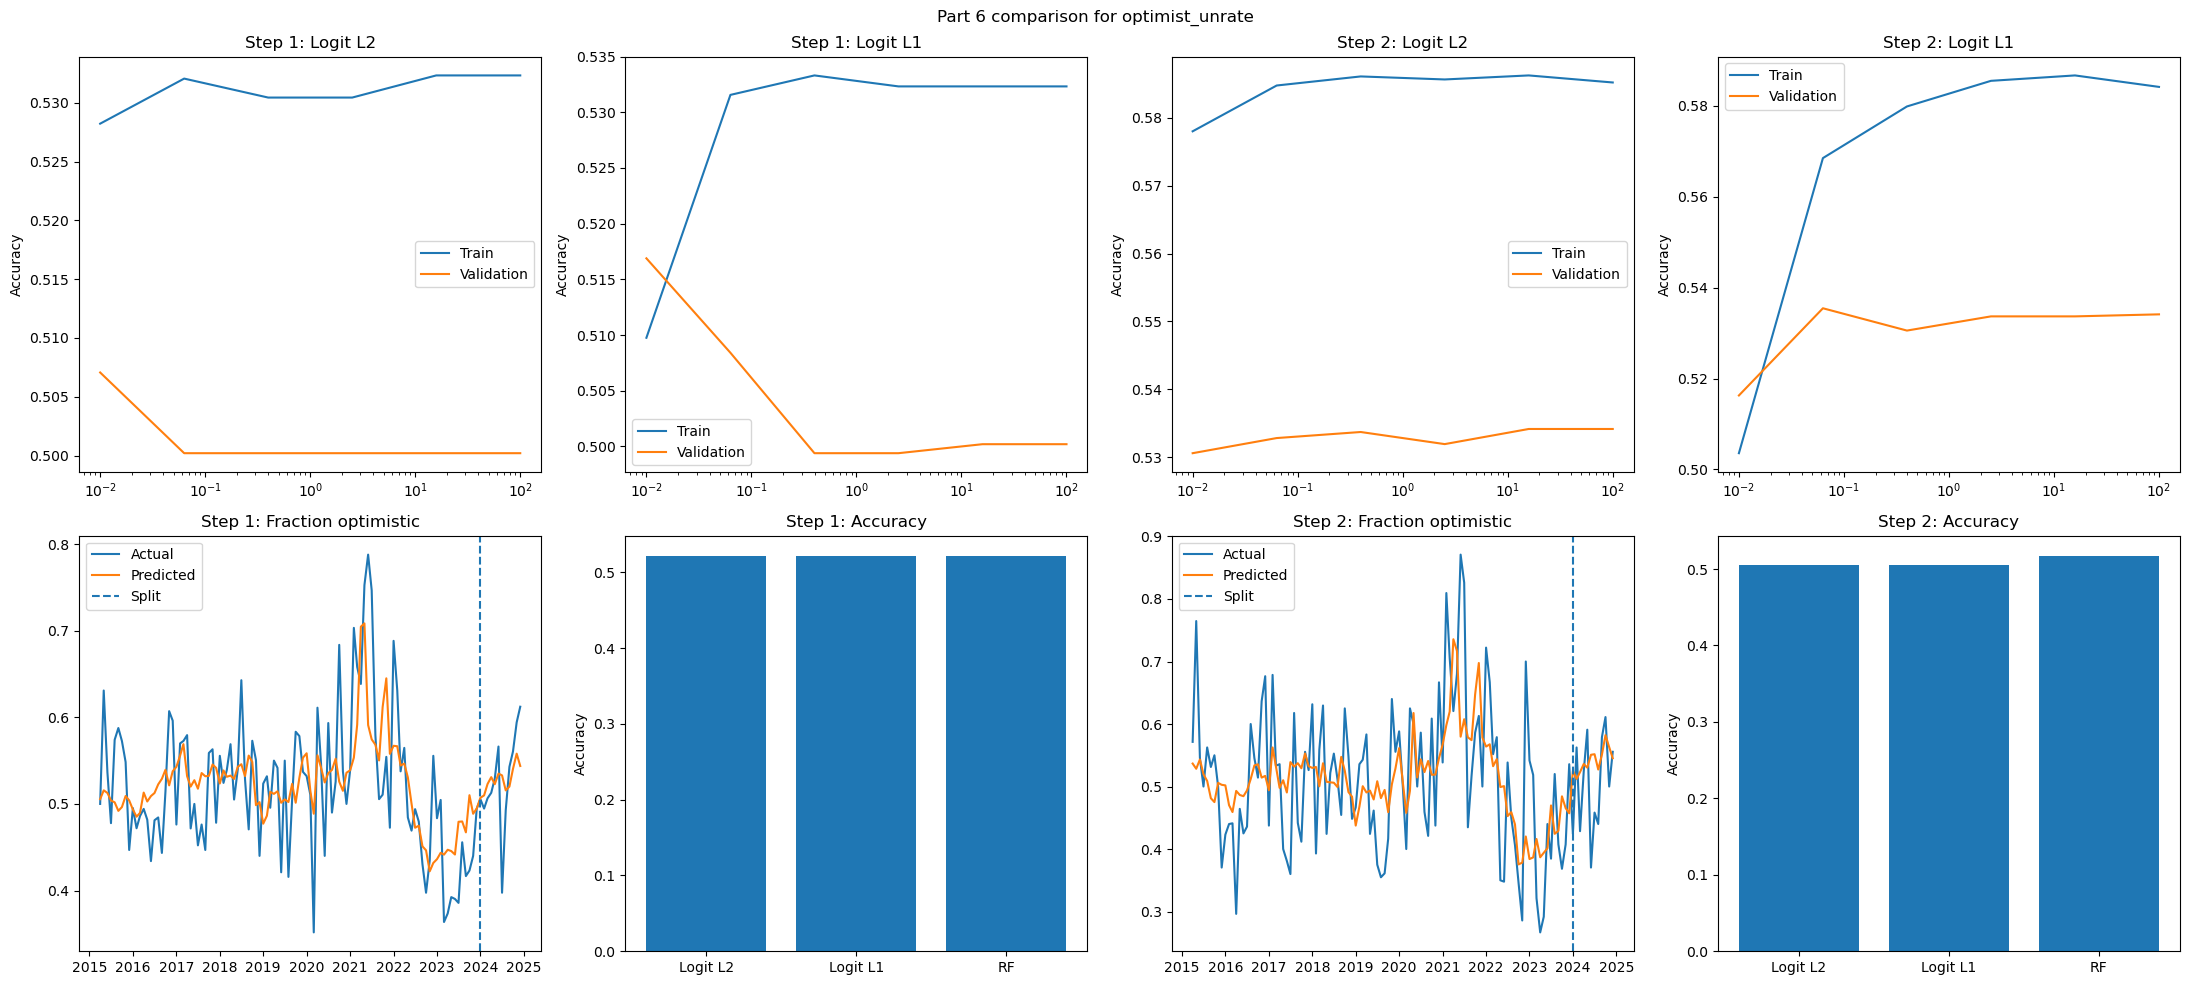

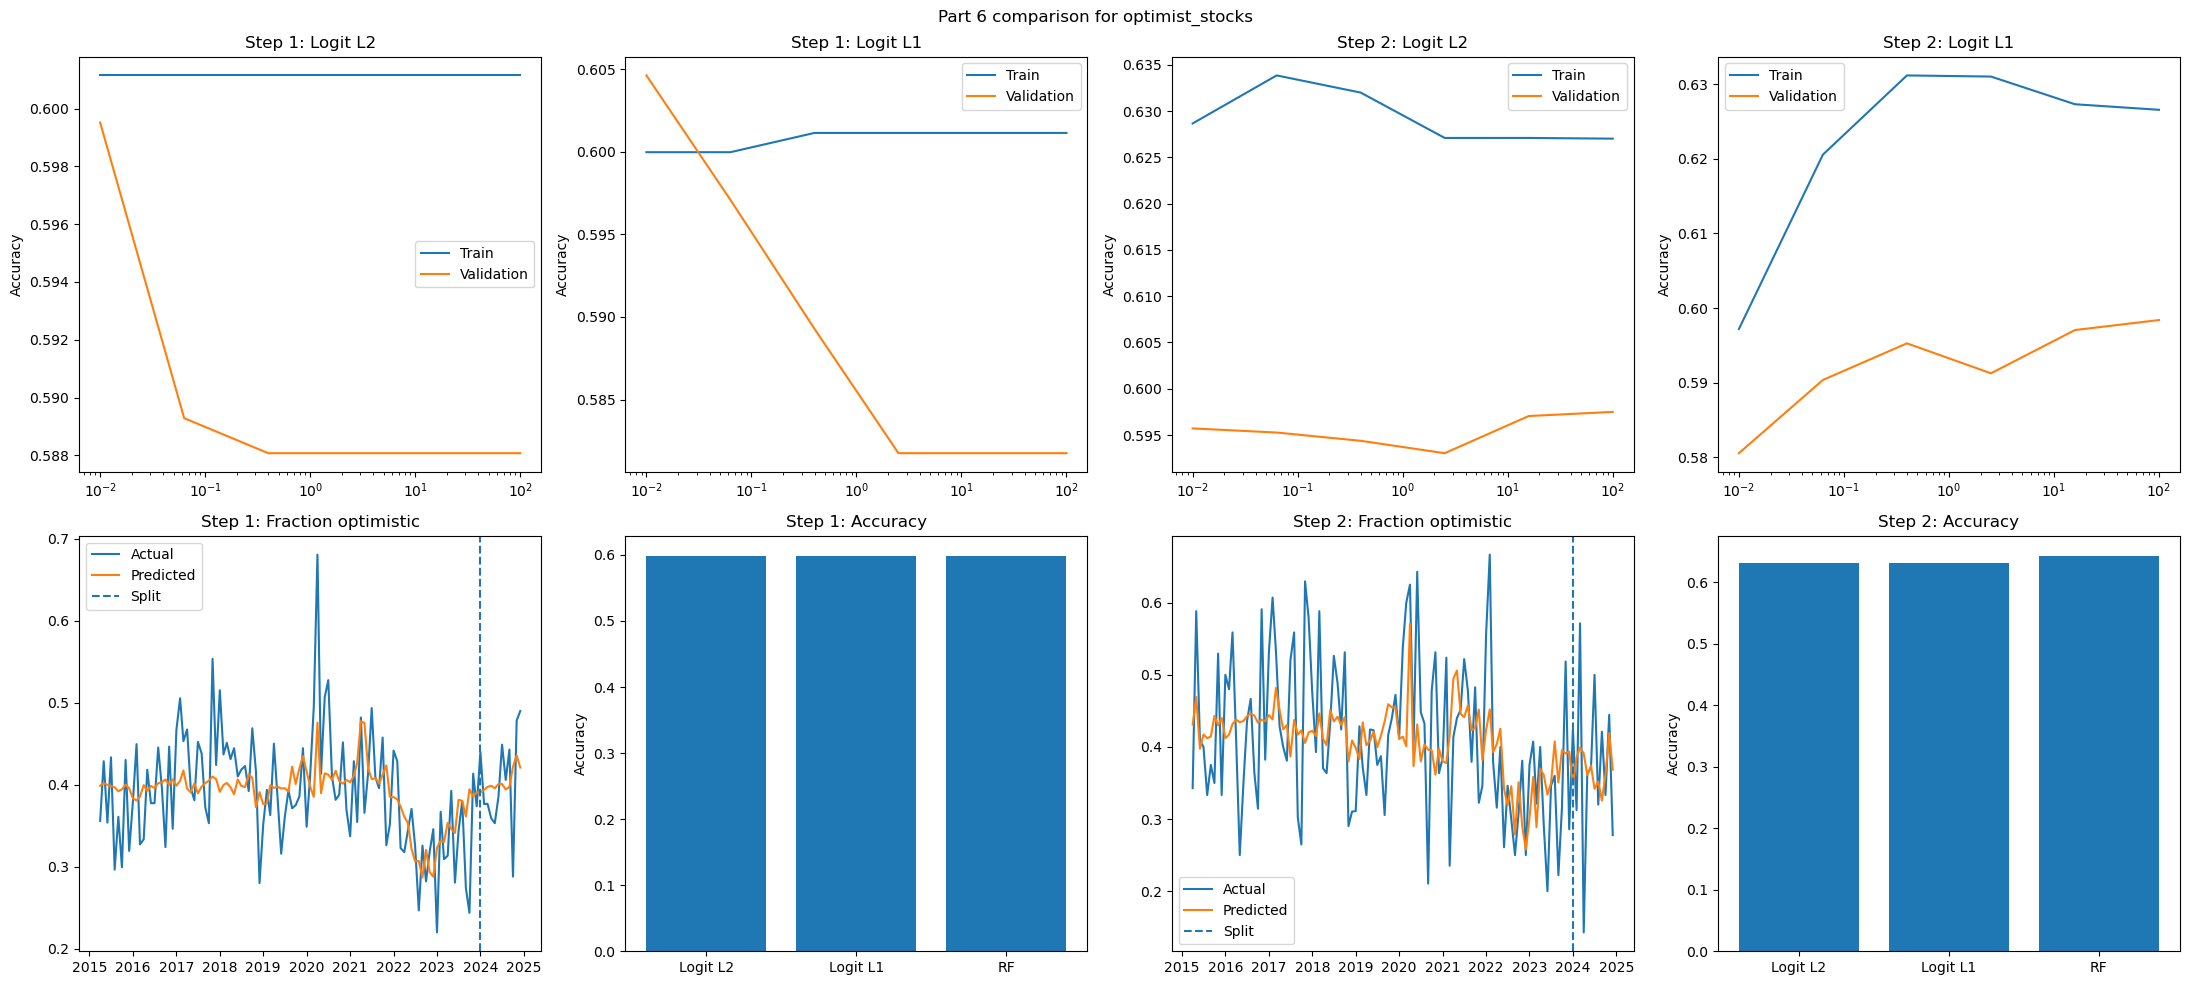

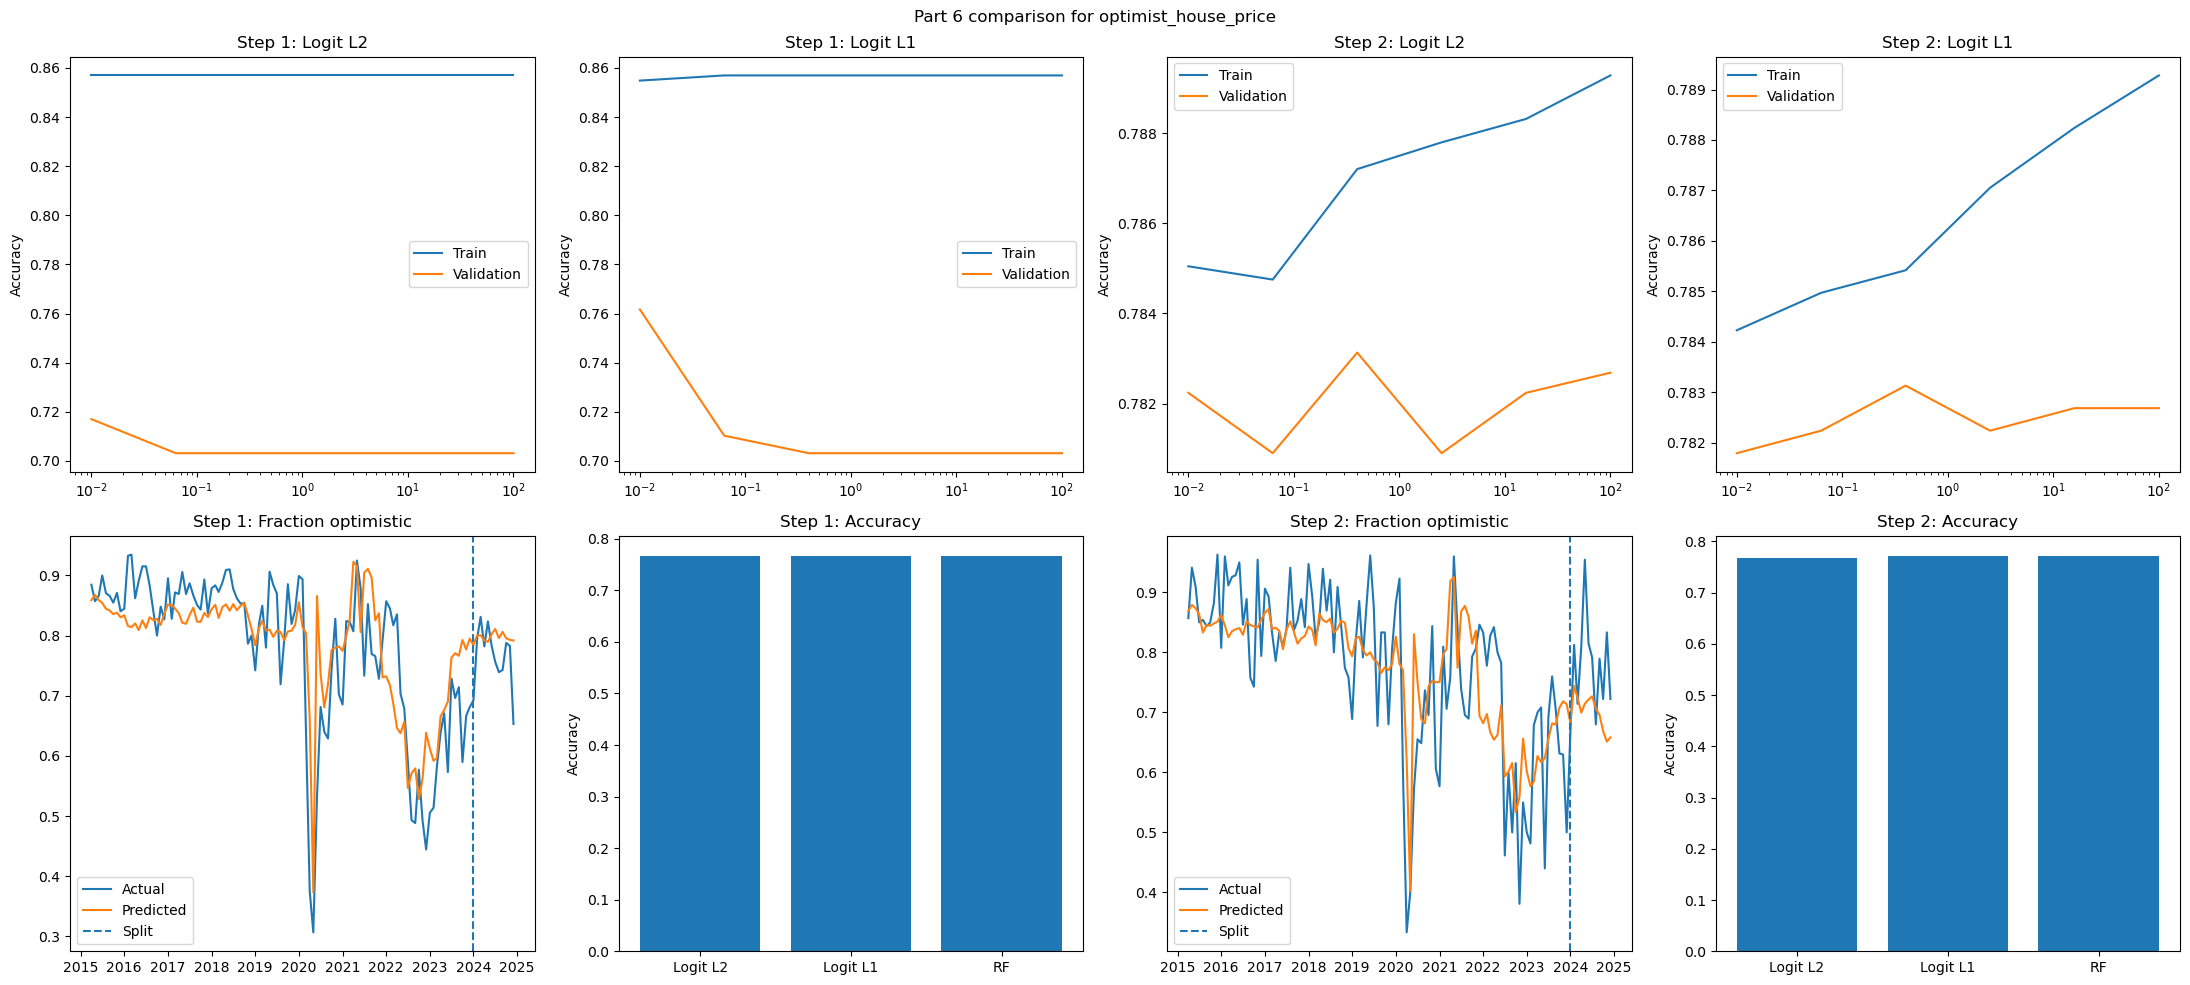

In [ ]:
# Create one 2x4 figure per binary target
# left half = Step 1, right half = Step 2

for target in binary_targets:
    fig, axes = plt.subplots(2, 4, figsize=(22, 10))

    # -------------------------
    # Top row: validation curves
    # -------------------------

    # Step 1 L2
    axes[0, 0].plot(C_values, results_step1_cls[target]["l2_train_acc_curve"], label="Train")
    axes[0, 0].plot(C_values, results_step1_cls[target]["l2_val_acc_curve"], label="Validation")
    axes[0, 0].set_xscale("log")
    axes[0, 0].set_title("Step 1: Logit L2")
    axes[0, 0].set_ylabel("Accuracy")
    axes[0, 0].legend()

    # Step 1 L1
    axes[0, 1].plot(C_values, results_step1_cls[target]["l1_train_acc_curve"], label="Train")
    axes[0, 1].plot(C_values, results_step1_cls[target]["l1_val_acc_curve"], label="Validation")
    axes[0, 1].set_xscale("log")
    axes[0, 1].set_title("Step 1: Logit L1")
    axes[0, 1].set_ylabel("Accuracy")
    axes[0, 1].legend()

    # Step 2 L2
    axes[0, 2].plot(C_values, results_step2_cls[target]["l2_train_acc_curve"], label="Train")
    axes[0, 2].plot(C_values, results_step2_cls[target]["l2_val_acc_curve"], label="Validation")
    axes[0, 2].set_xscale("log")
    axes[0, 2].set_title("Step 2: Logit L2")
    axes[0, 2].set_ylabel("Accuracy")
    axes[0, 2].legend()

    # Step 2 L1
    axes[0, 3].plot(C_values, results_step2_cls[target]["l1_train_acc_curve"], label="Train")
    axes[0, 3].plot(C_values, results_step2_cls[target]["l1_val_acc_curve"], label="Validation")
    axes[0, 3].set_xscale("log")
    axes[0, 3].set_title("Step 2: Logit L1")
    axes[0, 3].set_ylabel("Accuracy")
    axes[0, 3].legend()

    # -------------------------
    # Bottom row: fractions + accuracy
    # -------------------------

    # Step 1 actual vs predicted fractions
    axes[1, 0].plot(
        results_step1_cls[target]["actual_avg"]["year_month"],
        results_step1_cls[target]["actual_avg"][target],
        label="Actual"
    )
    axes[1, 0].plot(
        results_step1_cls[target]["pred_avg"]["year_month"],
        results_step1_cls[target]["pred_avg"]["pred"],
        label="Predicted"
    )
    axes[1, 0].axvline(pd.Timestamp("2024-01-01"), linestyle="--", label="Split")
    axes[1, 0].set_title("Step 1: Fraction optimistic")
    axes[1, 0].legend()

    # Step 1 accuracy
    axes[1, 1].bar(
        list(results_step1_cls[target]["accuracy"].keys()),
        list(results_step1_cls[target]["accuracy"].values())
    )
    axes[1, 1].set_title("Step 1: Accuracy")
    axes[1, 1].set_ylabel("Accuracy")

    # Step 2 actual vs predicted fractions
    axes[1, 2].plot(
        results_step2_cls[target]["actual_avg"]["year_month"],
        results_step2_cls[target]["actual_avg"][target],
        label="Actual"
    )
    axes[1, 2].plot(
        results_step2_cls[target]["pred_avg"]["year_month"],
        results_step2_cls[target]["pred_avg"]["pred"],
        label="Predicted"
    )
    axes[1, 2].axvline(pd.Timestamp("2024-01-01"), linestyle="--", label="Split")
    axes[1, 2].set_title("Step 2: Fraction optimistic")
    axes[1, 2].legend()

    # Step 2 accuracy
    axes[1, 3].bar(
        list(results_step2_cls[target]["accuracy"].keys()),
        list(results_step2_cls[target]["accuracy"].values())
    )
    axes[1, 3].set_title("Step 2: Accuracy")
    axes[1, 3].set_ylabel("Accuracy")

    plt.suptitle(f"Part 6 comparison for {target}")
    plt.tight_layout()
    plt.show()

In [ ]:
# Build a comparison table for classification accuracy
comparison_rows_cls = []

for target in binary_targets:
    for model_name in ["Logit L2", "Logit L1", "RF"]:
        comparison_rows_cls.append({
            "target": target,
            "model": model_name,
            "step1_accuracy": results_step1_cls[target]["accuracy"][model_name],
            "step2_accuracy": results_step2_cls[target]["accuracy"][model_name],
            "accuracy_change": results_step2_cls[target]["accuracy"][model_name] - results_step1_cls[target]["accuracy"][model_name],
        })

comparison_table_cls = pd.DataFrame(comparison_rows_cls)
comparison_table_cls

,target,model,step1_accuracy,step2_accuracy,accuracy_change
0,optimist_unrate,Logit L2,0.522026,0.505882,-0.016144
1,optimist_unrate,Logit L1,0.522026,0.505882,-0.016144
2,optimist_unrate,RF,0.522026,0.517647,-0.004379
3,optimist_stocks,Logit L2,0.599119,0.631373,0.032254
4,optimist_stocks,Logit L1,0.599119,0.631373,0.032254
5,optimist_stocks,RF,0.599119,0.643137,0.044018
6,optimist_house_price,Logit L2,0.767621,0.768627,0.001006
7,optimist_house_price,Logit L1,0.767621,0.772549,0.004928
8,optimist_house_price,RF,0.767621,0.772549,0.004928


## Discussion — Part 6

I repeat the predictive analysis using the binary optimism variables as targets. Since these are binary outcomes, I estimate classification models rather than regression models.

I begin with macro/finance variables only, and then extend the feature set by adding a small set of individual-level SCE variables. This parsimonious choice follows the guidance in the assignment to avoid including too many predictors.

For Logistic Regression with L2 and L1 penalties, I tune the regularization parameter using time-series cross-validation and plot validation curves based on accuracy. I also estimate a Random Forest model and tune a small set of hyperparameters.

Comparing Step 1 and Step 2 shows whether adding individual characteristics improves classification accuracy and the model’s ability to track the fraction of optimistic respondents over time.

# Part 7 — Conclusion

In this project, I built predictive models for household expectations using data from the Survey of Consumer Expectations (SCE), augmented with macroeconomic and financial variables.

## Main findings

Across all expectation variables, predictive performance was generally modest. Linear models such as OLS, Ridge, and Lasso achieved similar results, with only small improvements from regularization. For the classification tasks, logistic regression and random forests produced accuracies in the range of 50–65%, indicating limited predictability.

A key result is that models using only macroeconomic and financial variables performed worse than models that additionally included individual-level characteristics. Including variables such as demographic or survey-based features consistently improved both regression and classification performance, although the gains were relatively small.

## Model comparison

Among the models considered:
- Ridge and Lasso performed similarly to OLS in regression tasks, with slight improvements in some cases due to regularization.
- Logistic regression performed comparably to random forests in classification tasks, suggesting that more complex nonlinear models did not provide substantial gains.

Overall, no single model clearly dominated across all targets, but regularized linear models offered a good balance between performance and interpretability.

## Interpretation

The relatively low predictive performance suggests that household expectations are difficult to model using observable variables alone. This is consistent with the idea that expectations are influenced by unobserved factors such as beliefs, sentiment, and individual-specific information.

While macroeconomic conditions provide some explanatory power, they are not sufficient to fully capture the variation in expectations across individuals and over time.

## Final remarks

In conclusion, the results highlight both the usefulness and the limitations of machine learning methods in predicting economic expectations. While model performance can be improved by incorporating richer feature sets, a large share of the variation in expectations remains unexplained.

In [ ]:
# ============================================
# Summary table (manual)
# ============================================

summary_df = pd.DataFrame([

    # infl_1y
    ["infl_1y", "OLS", "macro", 15.08, -0.009],
    ["infl_1y", "Ridge", "macro + individual", 15.07, -0.008],
    ["infl_1y", "Lasso", "macro + individual", 15.06, -0.006],

    # house_price_change (replace with your numbers)
    ["house_price_change", "OLS", "macro", ..., ...],
    ["house_price_change", "Ridge", "macro + individual", ..., ...],
    ["house_price_change", "Lasso", "macro + individual", ..., ...],

    # prob_unrate_up (classification → use accuracy instead of RMSE)
    ["prob_unrate_up", "Logit", "macro", 0.52, None],
    ["prob_unrate_up", "Logit", "macro + individual", 0.55, None],

    # prob_stocks_up
    ["prob_stocks_up", "Logit", "macro", 0.60, None],
    ["prob_stocks_up", "Logit", "macro + individual", 0.63, None],

], columns=["target", "model", "features", "metric", "R2"])

summary_df

,target,model,features,metric,R2
0,infl_1y,OLS,macro,15.08,-0.009
1,infl_1y,Ridge,macro + individual,15.07,-0.008
2,infl_1y,Lasso,macro + individual,15.06,-0.006
3,house_price_change,OLS,macro,Ellipsis,Ellipsis
4,house_price_change,Ridge,macro + individual,Ellipsis,Ellipsis
5,house_price_change,Lasso,macro + individual,Ellipsis,Ellipsis
6,prob_unrate_up,Logit,macro,0.52,None
7,prob_unrate_up,Logit,macro + individual,0.55,None
8,prob_stocks_up,Logit,macro,0.6,None
9,prob_stocks_up,Logit,macro + individual,0.63,None
